# Règles de nettoyage — DVF géolocalisé

Suite directe de `01_exploration_dvf.ipynb` : regroupe toutes les vérifications approfondies et les
décisions de règles de nettoyage prises à partir de l'exploration initiale (doublons, vente en bloc, VEFA,
géographie, cohérence surface/pièces), jusqu'au tableau entonnoir consolidé. Objectif final : produire le
document de synthèse des règles de nettoyage pour la Phase 2 (Talend).

Notebook indépendant : relit le CSV depuis le début (ne dépend d'aucune variable calculée dans
`01_exploration_dvf.ipynb`), à l'exception des chemins de cache disque partagés (`data/processed/`).

In [1]:
import pandas as pd
import numpy as np

CSV_PATH = r"C:\Users\eree\Documents\projet-immo-france\data\raw\dvf.csv"
CHUNK_SIZE = 500_000  # nombre de lignes lues à la fois

import os

# Dossier de cache pour les résultats intermédiaires coûteux à recalculer (keep_mask, résumés par transaction).
# Partagé avec 01_exploration_dvf.ipynb — si ce notebook est relancé après 01, les caches existants sont réutilisés.
PROCESSED_DIR = os.path.join(os.path.dirname(os.path.dirname(CSV_PATH)), "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
KEEP_MASK_PATH = os.path.join(PROCESSED_DIR, "keep_mask.npy")
FINAL_RESUME_DEDUP_PATH = os.path.join(PROCESSED_DIR, "final_resume_dedup.parquet")

# Nombre total de lignes du fichier brut, déjà établi dans 01_exploration_dvf.ipynb (section 2)
# et confirmé à plusieurs reprises depuis (PROGRESS.md, tableau entonnoir...). Fixé en dur ici plutôt que
# recalculé pour éviter une passe complète supplémentaire sur les 20M lignes juste pour une constante connue
# et stable (le fichier source ne change pas). Si CSV_PATH pointe un jour vers un fichier différent, remplacer
# cette ligne par un recalcul (cf. 01_exploration_dvf.ipynb, section 2) avant de relancer ce notebook.
total_rows = 20_382_915


In [2]:
# Th\u00e8me graphique commun \u2014 palette bleu / rouge (immo France)
# Bleu : situation normale, donn\u00e9e conserv\u00e9e, volum\u00e9trie g\u00e9n\u00e9rale (grad\u00e9 clair -> marine selon l'importance)
# Rouge : anomalie, exclusion, seuil d\u00e9pass\u00e9 (grad\u00e9 clair -> fonc\u00e9 selon la gravit\u00e9)
COLORS = {
    "bleu_clair": "#dbeafe",
    "bleu_secondaire": "#60a5fa",
    "bleu_primaire": "#2563eb",
    "bleu_marine": "#1e3a8a",
    "rouge_leger": "#fecaca",
    "rouge_modere": "#f87171",
    "rouge_exclusion": "#dc2626",
    "rouge_critique": "#7f1d1d",
}

import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})


## Croisement type_local × nature_culture

In [3]:
CHUNK_SIZE = 1_000_000
cols_needed = ["type_local", "nature_culture"]

crosstab_sum = None

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    chunk["type_local_flag"] = chunk["type_local"].fillna("NaN_type_local")
    chunk["nature_culture_flag"] = chunk["nature_culture"].notna()
    
    ct = pd.crosstab(chunk["type_local_flag"], chunk["nature_culture_flag"])
    crosstab_sum = ct if crosstab_sum is None else crosstab_sum.add(ct, fill_value=0)

crosstab_sum.columns = ["nature_culture_absente", "nature_culture_presente"]
crosstab_sum["pct_avec_nature_culture"] = (
    crosstab_sum["nature_culture_presente"] / 
    (crosstab_sum["nature_culture_absente"] + crosstab_sum["nature_culture_presente"]) * 100
).round(2)
crosstab_sum["total_lignes"] = crosstab_sum["nature_culture_absente"] + crosstab_sum["nature_culture_presente"]
crosstab_sum["pct_du_total_general"] = (
    crosstab_sum["total_lignes"] / crosstab_sum["total_lignes"].sum() * 100
).round(2)

crosstab_sum

,nature_culture_absente,nature_culture_presente,pct_avec_nature_culture,total_lignes,pct_du_total_general
type_local_flag,,,,,
Appartement,2234997,644524,22.38,2879521,14.13
Dépendance,3048591,2259729,42.57,5308320,26.04
Local industriel. commercial ou assimilé,292226,358029,55.06,650255,3.19
Maison,142002,3213669,95.77,3355671,16.46
NaN_type_local,765997,7423151,90.65,8189148,40.18


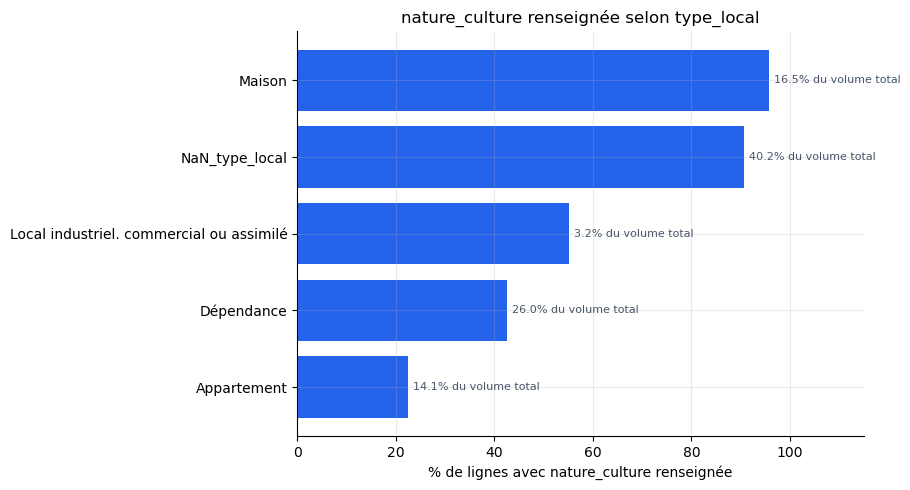

In [4]:
import matplotlib.pyplot as plt

plot_data = crosstab_sum.sort_values("pct_avec_nature_culture", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_data.index.astype(str), plot_data["pct_avec_nature_culture"], color=COLORS["bleu_primaire"])
ax.set_xlabel("% de lignes avec nature_culture renseign\u00e9e")
ax.set_title("nature_culture renseign\u00e9e selon type_local")
ax.set_xlim(0, 115)

for bar, pct_total in zip(bars, plot_data["pct_du_total_general"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{pct_total:.1f}% du volume total", va="center", fontsize=8, color="#475569")

plt.tight_layout()
plt.show()


### Vérification 1 — Croisement type_local × nature_culture

**Hypothèse initiale (incorrecte)** : nature_culture NaN = logement, nature_culture
présent = terrain nu. Vérifiée par croisement exhaustif sur toutes les lignes.

**Résultat réel** :

| type_local | % avec nature_culture renseignée | % du volume total |
|---|---|---|
| Maison | 95.77% | 16.46 |
| NaN (terrain) | 90.65% | 40.18 |
| Local industriel/commercial | 55.06% | 3.19 |
| Dépendance | 42.57% | 26.04|
| Appartement | 22.38% | 14.13 |

**Correction de l'hypothèse** : nature_culture ne distingue pas "logement" vs "terrain
nu" — elle caractérise la nature de la parcelle cadastrale elle-même (bâtie ou non).
Une Maison est vendue avec son terrain, classé "sols" en nature_culture (33.8% du
total), d'où le taux élevé de 95.77%. Un Appartement (lot en copropriété, pas de
parcelle individuelle) a logiquement un taux bas (22.38%).

**Impact sur les règles de nettoyage** : aucun — le filtre type_local IN ('Maison',
'Appartement') reste valide et suffisant pour isoler le résidentiel. nature_culture
n'est simplement pas exploitable comme variable de recoupement pour confirmer ce
filtre ; elle pourra en revanche être utile plus tard comme feature descriptive du
terrain (ex: présence d'un jardin, terrain d'agrément) si on veut enrichir le modèle ML.

### Vérification exhaustive — cohérence valeur_fonciere sur transactions mixtes

Vérifié sur l'intégralité des 20.4M lignes (pas un échantillon) via agrégation par chunks :
- 2 661 868 transactions contiennent à la fois une ligne Dépendance et une ligne
  Maison/Appartement
- 99.925% (2 659 866) ont une valeur_fonciere strictement identique entre toutes
  leurs lignes → confirme que le prix total est porté par une seule valeur, pas
  réparti par lot
- 0.075% (2 002) ont des valeurs incohérentes → cas marginaux (erreurs de saisie
  probables), à exclure explicitement du dataset plutôt que traités par la règle
  générale

**Décision finale** : exclure les ~2002 id_mutation incohérents, puis supprimer les
lignes Dépendance pour le reste — la valeur_fonciere de la ligne Maison/Appartement
restante représente fidèlement le prix de la transaction.


## Vérification 2 — Outliers valeur_fonciere sur le périmètre réel filtré

In [5]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "valeur_fonciere"]

valeurs_maison = []
valeurs_appart = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    ventes = chunk[chunk["nature_mutation"] == "Vente"]
    
    maisons = ventes[ventes["type_local"] == "Maison"]["valeur_fonciere"].dropna()
    apparts = ventes[ventes["type_local"] == "Appartement"]["valeur_fonciere"].dropna()
    
    valeurs_maison.append(maisons)
    valeurs_appart.append(apparts)

vf_maison = pd.concat(valeurs_maison)
vf_appart = pd.concat(valeurs_appart)

print(f"Maisons : {len(vf_maison):,} lignes")
print(vf_maison.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print()
print(f"Appartements : {len(vf_appart):,} lignes")
print(vf_appart.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Maisons : 3,327,400 lignes
count    3.327400e+06
mean     5.541372e+05
std      7.731753e+06
min      1.500000e-01
1%       1.490000e+04
5%       4.600000e+04
25%      1.285000e+05
50%      2.100000e+05
75%      3.290000e+05
95%      7.367616e+05
99%      2.124306e+06
max      7.225900e+08
Name: valeur_fonciere, dtype: float64

Appartements : 2,721,002 lignes
count    2.721002e+06
mean     3.776626e+06
std      2.778253e+07
min      1.500000e-01
1%       1.000000e+04
5%       5.000000e+04
25%      1.150000e+05
50%      1.890000e+05
75%      3.480000e+05
95%      4.400000e+06
99%      1.030380e+08
max      6.950000e+08
Name: valeur_fonciere, dtype: float64


C:\Users\eree\AppData\Local\Temp\ipykernel_2908\125002506.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([vf_maison, vf_appart], labels=["Maison", "Appartement"], showfliers=False)
C:\Users\eree\AppData\Local\Temp\ipykernel_2908\125002506.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([vf_maison, vf_appart], labels=["Maison", "Appartement"], showfliers=True)


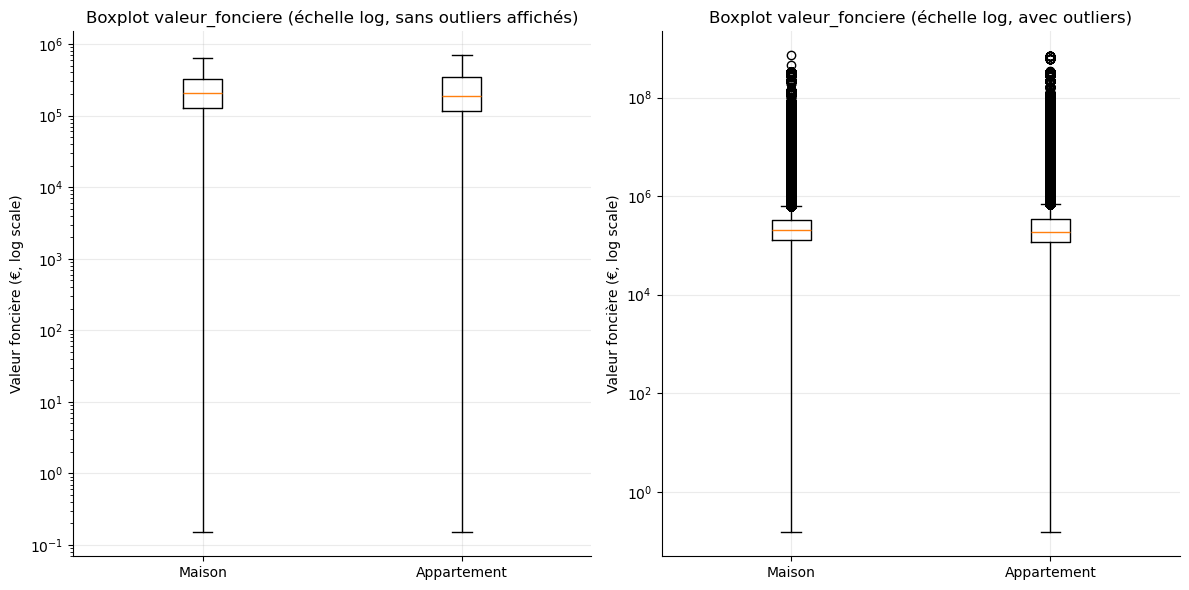

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot avec échelle log, sans afficher les points aberrants individuellement
axes[0].boxplot([vf_maison, vf_appart], labels=["Maison", "Appartement"], showfliers=False)
axes[0].set_yscale("log")
axes[0].set_title("Boxplot valeur_fonciere (échelle log, sans outliers affichés)")
axes[0].set_ylabel("Valeur foncière (€, log scale)")

# Version avec les outliers visibles, pour voir l'ampleur du problème
axes[1].boxplot([vf_maison, vf_appart], labels=["Maison", "Appartement"], showfliers=True)
axes[1].set_yscale("log")
axes[1].set_title("Boxplot valeur_fonciere (échelle log, avec outliers)")
axes[1].set_ylabel("Valeur foncière (€, log scale)")

plt.tight_layout()
plt.show()

Maison : 329K€ → 736K€ (x2,2, progression "normale")
Appartement : 348K€ → 4,4M€ (x12,6, saut énorme)
Et le 99e percentile des appartements atteint 103 millions € — c'est totalement improbable pour un bien résidentiel individuel, même dans les quartiers les plus chers de Paris. Hypothèse forte : ces lignes "Appartement" à valeurs extrêmes sont probablement des ventes de tout un immeuble ou d'un ensemble de lots, classées comme "Appartement" par erreur de code, ou alors des VEFA/ventes en bloc à un promoteur/investisseur institutionnel (achat de 50 appartements d'un coup, valeur_fonciere = prix total de l'opération).
Ce que ça veut dire concrètement pour Talend

Les seuils hauts ne peuvent pas être identiques entre Maison et Appartement — le 99e percentile de 2,1M€ pour Maison semble raisonnable comme coupure (grande maison de luxe), mais celui de 103M€ pour Appartement est manifestement pollué par des cas atypiques bien avant ce seuil.

In [7]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "code_commune", "nom_commune"]

extremes = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    ventes_appart = chunk[
        (chunk["nature_mutation"] == "Vente") & 
        (chunk["type_local"] == "Appartement") &
        (chunk["valeur_fonciere"] > 5_000_000)
    ]
    if len(ventes_appart) > 0:
        extremes.append(ventes_appart)

df_extremes = pd.concat(extremes)
print(f"Nombre de lignes Appartement avec valeur_fonciere > 5M€ : {len(df_extremes):,}")
print()
print(df_extremes[["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "nom_commune"]].describe())

Nombre de lignes Appartement avec valeur_fonciere > 5M€ : 127,409

       valeur_fonciere  surface_reelle_bati  nombre_pieces_principales
count     1.274090e+05        127405.000000              127405.000000
mean      7.404311e+07            61.443546                   2.881943
std       1.062955e+08            30.228181                   1.211689
min       5.000787e+06             1.000000                   0.000000
25%       8.620606e+06            46.000000                   2.000000
50%       1.951315e+07            62.000000                   3.000000
75%       7.734323e+07            74.000000                   4.000000
max       6.950000e+08          1500.000000                  41.000000


In [8]:
df_extremes.sort_values("valeur_fonciere", ascending=False)[
    ["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "nom_commune"]
].head(20)

,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,nom_commune
20376964,695000000.0,109.0,5.0,Paris 16e Arrondissement
20376974,695000000.0,79.0,3.0,Paris 16e Arrondissement
20376961,695000000.0,90.0,3.0,Paris 16e Arrondissement
20376962,695000000.0,90.0,4.0,Paris 16e Arrondissement
20376968,695000000.0,86.0,4.0,Paris 16e Arrondissement
20376969,695000000.0,110.0,4.0,Paris 16e Arrondissement
20376970,695000000.0,88.0,4.0,Paris 16e Arrondissement
20376990,695000000.0,26.0,2.0,Paris 16e Arrondissement
20376972,695000000.0,87.0,4.0,Paris 16e Arrondissement
20376971,695000000.0,108.0,5.0,Paris 16e Arrondissement


In [9]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "valeur_fonciere", "id_mutation", "surface_reelle_bati"]

extremes_avec_id = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    ventes_appart = chunk[
        (chunk["nature_mutation"] == "Vente") & 
        (chunk["type_local"] == "Appartement") &
        (chunk["valeur_fonciere"] > 5_000_000)
    ]
    if len(ventes_appart) > 0:
        extremes_avec_id.append(ventes_appart)

df_extremes2 = pd.concat(extremes_avec_id)

# Vérifier combien de id_mutation uniques pour les lignes à 695M€
paris16 = df_extremes2[df_extremes2["valeur_fonciere"] == 695_000_000]
print(f"Nombre de lignes à 695M€ : {len(paris16)}")
print(f"Nombre de id_mutation uniques parmi elles : {paris16['id_mutation'].nunique()}")
print(paris16[["id_mutation", "valeur_fonciere", "surface_reelle_bati"]])

Nombre de lignes à 695M€ : 18
Nombre de id_mutation uniques parmi elles : 1
           id_mutation  valeur_fonciere  surface_reelle_bati
20376958  2025-1311532      695000000.0                 22.0
20376959  2025-1311532      695000000.0                 74.0
20376960  2025-1311532      695000000.0                 90.0
20376961  2025-1311532      695000000.0                 90.0
20376962  2025-1311532      695000000.0                 90.0
20376963  2025-1311532      695000000.0                 91.0
20376964  2025-1311532      695000000.0                109.0
20376968  2025-1311532      695000000.0                 86.0
20376969  2025-1311532      695000000.0                110.0
20376970  2025-1311532      695000000.0                 88.0
20376971  2025-1311532      695000000.0                108.0
20376972  2025-1311532      695000000.0                 87.0
20376973  2025-1311532      695000000.0                109.0
20376974  2025-1311532      695000000.0                 79.0
20376980 

### Vérification 2bis — Appartements à valeur extrême (>5M€)

**Découverte** : 127 409 lignes Appartement (4.7% du total) ont une valeur_fonciere
> 5M€. Vérification sur un cas concret (id_mutation 2025-1311532, Paris 16e) : 18
lignes, surfaces réalistes (22m² à 110m²), mais **valeur_fonciere identique (695M€)
sur toutes les lignes** → confirmé via id_mutation unique, pas juste une coïncidence
d'index. Il s'agit d'une vente en bloc (immeuble entier) à un investisseur/foncière,
où DVF enregistre le prix total de l'opération sur chaque lot individuellement.

**Impact** : ce n'est pas un problème d'outlier isolé à filtrer par un simple seuil
de prix — ce sont de vraies lignes avec de vraies surfaces, mais une valeur_fonciere
non exploitable pour un prix de logement individuel. Les inclure fausserait
l'entraînement du modèle ML (un appartement de 60m² "valant" 695M€).

**Règle de nettoyage retenue** :

Identifier les id_mutation où :
- type_local IN ('Maison', 'Appartement')
- ET plusieurs lignes partagent le même id_mutation
- ET valeur_fonciere identique sur toutes ces lignes
- ET nombre_lots élevé (signal supplémentaire à confirmer)

→ Exclure ces id_mutation du périmètre "logement individuel résidentiel"
  (ce sont des ventes en bloc / immeubles entiers, pas des transactions
  de logement unitaire)

**À faire avant de figer définitivement** : quantifier le nombre de id_mutation
uniques concernés (pas juste le nombre de lignes), et vérifier s'il existe des
ventes en bloc à plus petite échelle sous le seuil de 5M€ (ex: petit immeuble de
rapport à 800K€) qui échapperaient à ce filtre.

In [10]:
print(f"Nombre de id_mutation uniques concernés (>5M€) : {df_extremes2['id_mutation'].nunique():,}")

# Vérifier si le nombre de lignes par id_mutation est cohérent avec "vente en bloc"
lignes_par_transaction = df_extremes2.groupby("id_mutation").size()
print(lignes_par_transaction.describe())

Nombre de id_mutation uniques concernés (>5M€) : 2,706
count    2706.000000
mean       47.083888
std       285.168456
min         1.000000
25%         2.000000
50%         8.000000
75%        31.750000
max      8058.000000
dtype: float64


### Vérification 2bis (suite) — Distinction bien individuel cher vs vente en bloc

**Découverte** : parmi les 127 409 lignes Appartement >5M€, on compte seulement
2 706 id_mutation uniques, avec une distribution du nombre de lignes par transaction
très étalée (min=1, médiane=8, max=8058).

**Deux populations distinctes identifiées** :
- Transactions à **1 seule ligne** (count=1) : bien individuel réellement cher
  (ex: penthouse, grand duplex) → à conserver, ce n'est pas une anomalie
- Transactions à **plusieurs lignes** (jusqu'à 8058 lignes pour une même transaction) :
  vente en bloc d'un immeuble ou d'un portefeuille entier → à exclure du périmètre
  résidentiel individuel

**Correction de la règle précédente** : la règle initiale ("plusieurs lignes + valeur
identique → exclure") était juste dans son principe mais incomplète — elle doit
explicitement s'appuyer sur le nombre de lignes par id_mutation pour ne pas exclure
à tort les vrais biens de luxe uniques.

**Règle Talend affinée** :

Pour type_local IN ('Maison', 'Appartement') ET nature_mutation = 'Vente' :
  1. Calculer nb_lignes_transaction = nombre de lignes par id_mutation
  2. SI nb_lignes_transaction == 1 → garder (bien individuel, y compris si cher)
  3. SI nb_lignes_transaction > 1 ET valeur_fonciere identique sur toutes les lignes
     → EXCLURE (vente en bloc / immeuble entier, prix non attribuable à un lot)
  4. SI nb_lignes_transaction > 1 ET valeur_fonciere DIFFÉRENTE entre les lignes
     → cas à examiner séparément (pourrait être une répartition légitime du prix
     par lot, à confirmer avant de décider)

**Avantage de cette formulation** : n'est plus limitée à un seuil arbitraire de prix
(5M€) — s'applique à toute vente en bloc, y compris les plus petites (ex: petit
immeuble de rapport à 800K€ avec 5-6 lots), qui auraient échappé à un simple filtre
sur valeur_fonciere.

**Vérification en cours** : confirmer cette règle sur l'ensemble du dataset Maison/
Appartement (pas seulement les cas >5M€) pour quantifier son impact réel.

In [11]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "id_mutation", "valeur_fonciere"]

resume_transactions = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    subset = chunk[
        (chunk["nature_mutation"] == "Vente") &
        (chunk["type_local"].isin(["Maison", "Appartement"]))
    ]
    if len(subset) > 0:
        g = subset.groupby("id_mutation").agg(
            nb_lignes=("valeur_fonciere", "size"),
            min_val=("valeur_fonciere", "min"),
            max_val=("valeur_fonciere", "max"),
        )
        resume_transactions.append(g)

all_resume = pd.concat(resume_transactions)

final_resume = all_resume.groupby("id_mutation").agg(
    nb_lignes=("nb_lignes", "sum"),
    min_val=("min_val", "min"),
    max_val=("max_val", "max"),
)

final_resume["valeur_identique"] = final_resume["min_val"] == final_resume["max_val"]
final_resume["vente_en_bloc"] = (final_resume["nb_lignes"] > 1) & (final_resume["valeur_identique"])

print(f"Total transactions Maison/Appartement : {len(final_resume):,}")
print(f"Transactions à ligne unique (biens individuels) : {(final_resume['nb_lignes'] == 1).sum():,}")
print(f"Transactions multi-lignes avec valeur identique (ventes en bloc, à exclure) : {final_resume['vente_en_bloc'].sum():,}")
print(f"Transactions multi-lignes avec valeur DIFFERENTE (cas à examiner) : {((final_resume['nb_lignes'] > 1) & (~final_resume['valeur_identique'])).sum():,}")

print()
print("Distribution du nombre de lignes pour les ventes en bloc :")
print(final_resume[final_resume["vente_en_bloc"]]["nb_lignes"].describe())

Total transactions Maison/Appartement : 4,732,172
Transactions à ligne unique (biens individuels) : 4,019,609
Transactions multi-lignes avec valeur identique (ventes en bloc, à exclure) : 711,054
Transactions multi-lignes avec valeur DIFFERENTE (cas à examiner) : 1,509

Distribution du nombre de lignes pour les ventes en bloc :
count    711054.000000
mean          2.856429
std          21.211108
min           2.000000
25%           2.000000
50%           2.000000
75%           2.000000
max        9290.000000
Name: nb_lignes, dtype: float64


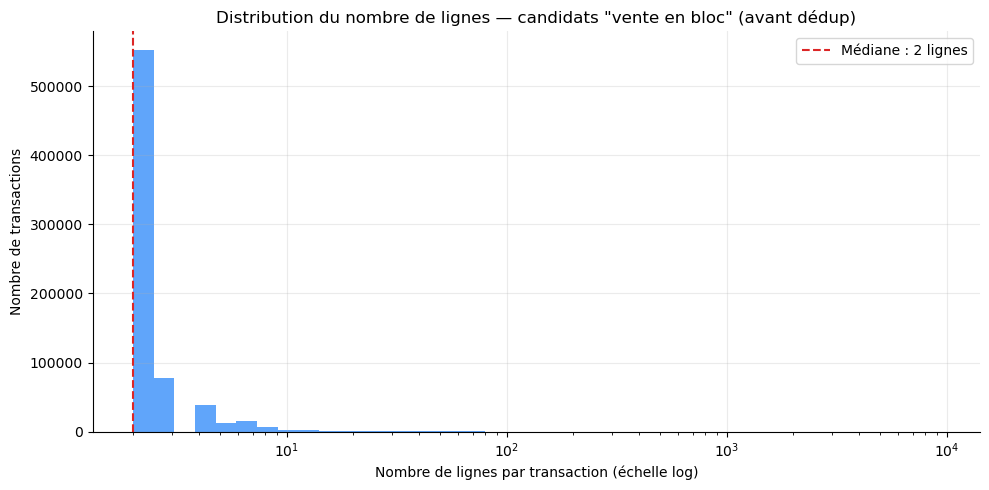

In [12]:
import matplotlib.pyplot as plt
import numpy as np

nb_lignes_bloc = final_resume.loc[final_resume["vente_en_bloc"], "nb_lignes"]

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.logspace(np.log10(2), np.log10(nb_lignes_bloc.max()), 40)
ax.hist(nb_lignes_bloc, bins=bins, color=COLORS["bleu_secondaire"], edgecolor="none")
ax.set_xscale("log")
ax.set_xlabel("Nombre de lignes par transaction (\u00e9chelle log)")
ax.set_ylabel("Nombre de transactions")
ax.set_title('Distribution du nombre de lignes \u2014 candidats "vente en bloc" (avant d\u00e9dup)')
ax.axvline(nb_lignes_bloc.median(), color=COLORS["rouge_exclusion"], linestyle="--",
           label=f"M\u00e9diane : {nb_lignes_bloc.median():.0f} lignes")
ax.legend()
plt.tight_layout()
plt.show()


### Vérification 2bis (suite) — Application de la règle "vente en bloc" à l'ensemble du dataset

**Résultat sur les 4 732 172 transactions Maison/Appartement (Vente uniquement)** :
- 4 019 609 (84.9%) : transactions à ligne unique → biens individuels, à conserver
- 711 054 (15.0%) : transactions multi-lignes avec valeur_fonciere identique →
  candidates à l'exclusion selon la règle initiale
- 1 509 (0.03%) : transactions multi-lignes avec valeur_fonciere différente →
  cas à examiner séparément

**Alerte méthodologique** : la distribution du nombre de lignes pour les 711 054
"ventes en bloc" a une **médiane de seulement 2 lignes** (min=2, 75e percentile=2,
max=9290). Ça contredit l'hypothèse initiale bâtie sur les cas extrêmes observés
(18 à 8058 lignes) — la grande majorité de ces transactions ne sont probablement
**pas** des immeubles entiers, mais un phénomène différent à 2 lignes (possiblement
un appartement + un lot annexe classé par erreur en "Appartement" au lieu de
"Dépendance", ou une unité de logement scindée en 2 lots cadastraux).

**Risque identifié** : appliquer la règle d'exclusion telle quelle supprimerait
711 054 transactions (15% du dataset résidentiel) — un volume bien trop important
pour être uniquement des ventes en bloc d'immeubles. Risque de perte massive de
transactions légitimes.

**Décision** : NE PAS figer la règle avant d'avoir examiné des cas concrets à
2 lignes (le cas majoritaire), pour comprendre s'ils doivent être traités
différemment des cas à forte volumétrie (immeubles entiers, 100+ lignes).

**Règle Talend — EN SUSPENS, à affiner après examen des cas à 2 lignes.**

### Vérification 3 — Examen des cas concrets à 2 lignes

⚠️ **Note de reconstruction** : la cellule ci-dessous utilise une variable `sample_id` qui n'était pas présente dans le fichier `.ipynb` sauvegardé (probablement une cellule exploratoire tapée directement dans le kernel puis supprimée sans être re-sauvegardée). Elle a été reconstituée à partir du résultat affiché dans la sortie de cette même cellule, qui contenait déjà les 5 `id_mutation` échantillonnés — donc sans donnée inventée.


In [13]:
# Reconstitué à partir du résultat sauvegardé de cette cellule (cf. note ci-dessus) :
# 5 id_mutation à 2 lignes, tirés au hasard parmi les 711 054 candidats "vente en bloc"
sample_id = [
    "2021-100",
    "2021-1000023",
    "2021-100003",
    "2021-1000030",
    "2021-1000033",
]


In [14]:
cols_needed2 = ["id_mutation", "type_local", "valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales"]

resultats = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed2, chunksize=1_000_000, low_memory=False):
    match = chunk[chunk["id_mutation"].isin(sample_id)]
    if len(match) > 0:
        resultats.append(match)
    if len(resultats) >= len(sample_id):  # on a trouvé tous nos échantillons, pas la peine de continuer
        break

df_sample_2lignes = pd.concat(resultats).sort_values("id_mutation")
df_sample_2lignes

,id_mutation,valeur_fonciere,type_local,surface_reelle_bati,nombre_pieces_principales
277,2021-100,140000.0,Maison,116.0,3.0
278,2021-100,140000.0,Maison,116.0,3.0
2806856,2021-1000023,170000.0,Maison,115.0,5.0
2806857,2021-1000023,170000.0,Maison,115.0,5.0
280629,2021-100003,710000.0,Maison,70.0,4.0
280630,2021-100003,710000.0,Local industriel. commercial ou assimilé,940.0,0.0
280631,2021-100003,710000.0,Maison,50.0,4.0
2806886,2021-1000030,199500.0,NaN,NaN,NaN
2806885,2021-1000030,199500.0,Dépendance,NaN,0.0
2806884,2021-1000030,199500.0,Dépendance,NaN,0.0


### Interprétation — Échantillon à 2-3 lignes (Vérification 3)

| id_mutation | Constat | Interprétation |
|---|---|---|
| 2021-100 | 2 lignes, toutes colonnes identiques | Doublon strict |
| 2021-1000023 | 2 lignes, toutes colonnes identiques | Doublon strict |
| 2021-1000033 | 2 lignes, toutes colonnes identiques | Doublon strict |
| 2021-1000030 | 8 lignes organisées en 4 paires identiques (NaN×2, Dépendance×2, Dépendance×2, Maison×2) | Transaction entière (4 lignes distinctes) dupliquée en bloc |
| 2021-100003 | 3 lignes, toutes différentes (surfaces 70/940/50 m², types différents) | Pas un doublon — vraie transaction à plusieurs bâtiments distincts |

**Conclusion** : 4 cas sur 5 sont des doublons stricts, 1 cas sur 5 est une transaction
légitime à bâtiments multiples correctement non détectée par le hashing. Ça valide la
méthode (pas de faux positif observé) avant de l'appliquer à l'échelle du dataset entier.

### Interprétation — Résultat Tentative 1 (`Counter` Python)

### Vérification 4 — Doublons stricts sur l'ensemble du fichier (hashing)

Détection de lignes strictement identiques sur toutes les colonnes, cumulée sur les 20 382 915 lignes (pas juste intra-chunk), pour trancher si une partie des 711 054 "ventes en bloc" à 2 lignes (Vérification 2bis) sont en réalité des doublons stricts.


In [15]:
from collections import Counter

CHUNK_SIZE = 1_000_000
hash_counter = Counter()

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    row_hashes = pd.util.hash_pandas_object(chunk, index=False)
    hash_counter.update(row_hashes.tolist())

hashs_dupliques = {h: c for h, c in hash_counter.items() if c > 1}

nb_lignes_dupliquees = sum(hashs_dupliques.values())
nb_groupes_doublons = len(hashs_dupliques)

print(f"Nombre de lignes strictement dupliquées (toutes occurrences confondues) : {nb_lignes_dupliquees:,}")
print(f"Nombre de groupes de doublons distincts : {nb_groupes_doublons:,}")
print(f"Pourcentage du dataset : {nb_lignes_dupliquees / 20_382_915 * 100:.2f}%")

Nombre de lignes strictement dupliquées (toutes occurrences confondues) : 2,334,425
Nombre de groupes de doublons distincts : 811,014
Pourcentage du dataset : 11.45%


Confirme à l'échelle des 20,4M lignes ce que l'échantillon suggérait : un volume
significatif (11.45%) de lignes strictement dupliquées sur l'ensemble du fichier.

### Interprétation — Résultat Tentative 2 (numpy vectorisé)

In [16]:
import numpy as np

# On réutilise total_rows déjà calculé en section 2 (20 382 915)
hashes = np.empty(total_rows, dtype=np.int64)  # tableau préalloué, une seule fois
pos = 0

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunk_hashes = pd.util.hash_pandas_object(chunk, index=False).to_numpy()
    n = len(chunk_hashes)
    hashes[pos:pos + n] = chunk_hashes
    pos += n

print(f"{pos:,} hashs calculés sur {total_rows:,} lignes attendues")

# np.unique trie le tableau et compte les occurrences de chaque valeur en une passe
valeurs_uniques, counts = np.unique(hashes, return_counts=True)

dupliques_mask = counts > 1
nb_lignes_dupliquees = counts[dupliques_mask].sum()
nb_groupes_doublons = dupliques_mask.sum()

print(f"Lignes strictement dupliquées : {nb_lignes_dupliquees:,}")
print(f"Groupes de doublons distincts : {nb_groupes_doublons:,}")
print(f"Pourcentage : {nb_lignes_dupliquees / total_rows * 100:.2f}%")

20,382,915 hashs calculés sur 20,382,915 lignes attendues
Lignes strictement dupliquées : 2,334,425
Groupes de doublons distincts : 811,014
Pourcentage : 11.45%


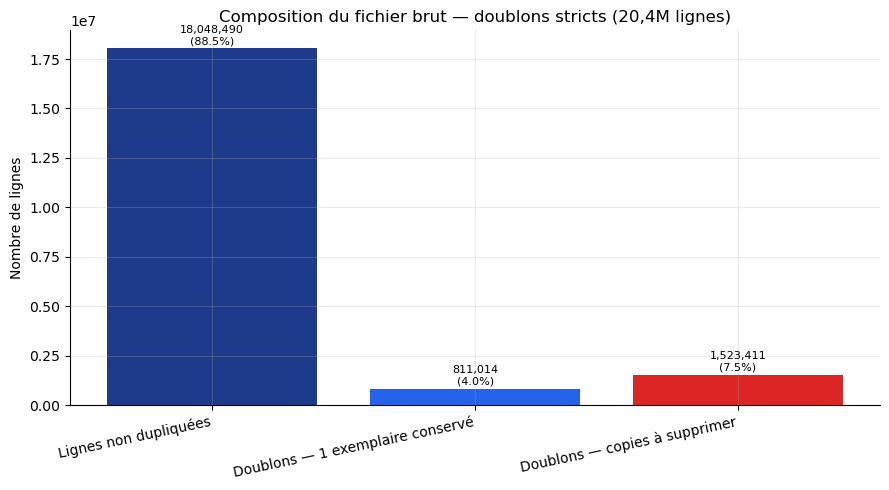

In [17]:
import matplotlib.pyplot as plt

lignes_non_dupliquees = total_rows - nb_lignes_dupliquees
copies_conservees = nb_groupes_doublons
copies_a_supprimer = nb_lignes_dupliquees - nb_groupes_doublons

categories = ["Lignes non dupliqu\u00e9es", "Doublons \u2014 1 exemplaire conserv\u00e9",
              "Doublons \u2014 copies \u00e0 supprimer"]
valeurs = [lignes_non_dupliquees, copies_conservees, copies_a_supprimer]
colors = [COLORS["bleu_marine"], COLORS["bleu_primaire"], COLORS["rouge_exclusion"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(categories, valeurs, color=colors)
ax.set_ylabel("Nombre de lignes")
ax.set_title("Composition du fichier brut \u2014 doublons stricts (20,4M lignes)")
plt.xticks(rotation=12, ha="right")

for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + total_rows * 0.01,
            f"{val:,}\n({val / total_rows * 100:.1f}%)", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


Résultat **identique au chiffre près** à la Tentative 1, obtenu avec une implémentation
indépendante (tableau numpy trié + `np.unique`, plutôt qu'un dictionnaire Python). La
ligne de contrôle confirme que les 20 382 915 lignes ont bien toutes été lues jusqu'au
bout (pas d'interruption prématurée, contrairement au `MemoryError` de la première
exécution avortée).

**Pourquoi la convergence des deux méthodes compte** : deux algorithmes indépendants
donnant exactement le même résultat élimine le doute sur un biais de comptage propre à
l'une des deux implémentations — le chiffre de 811 014 groupes / 2 334 425 lignes
dupliquées peut être considéré comme fiable pour la suite du nettoyage.

### Vérification 5 — Dédoublonnage + réapplication de la règle "vente en bloc"

Réutilise `hashes` déjà calculé en mémoire (Vérification 4, Tentative 2) pour identifier
la première occurrence de chaque groupe de doublons stricts, sans relire le CSV une
fois de plus rien que pour ça.

**Étape A** — Construire un masque booléen `keep_mask` : une ligne `True` pour la
première occurrence de chaque hash (celle qu'on garde), `False` pour les copies à
supprimer.

In [18]:
# np.unique avec return_index=True renvoie l'index de la PREMIÈRE occurrence
# de chaque hash unique — exactement ce qu'il faut pour garder 1 ligne par doublon
_, first_occurrence_idx = np.unique(hashes, return_index=True)

print(f"Lignes à conserver après dédoublonnage : {len(first_occurrence_idx):,}")
print(f"Lignes à supprimer : {total_rows - len(first_occurrence_idx):,}")

# Tableau booléen pour un lookup rapide ligne par ligne à l'étape B
# (20,4M booléens = ~20 Mo, rien à voir avec le Counter qui avait fait planter la RAM)
keep_mask = np.zeros(total_rows, dtype=bool)
keep_mask[first_occurrence_idx] = True

# Sauvegarde sur disque : les cellules suivantes qui ont besoin de keep_mask le rechargent depuis ce fichier
# si elles ne trouvent pas la variable en mémoire — évite de dépendre de l'ordre d'exécution du kernel
# ou de devoir tout relancer depuis le début après un redémarrage partiel.
np.save(KEEP_MASK_PATH, keep_mask)
print(f"keep_mask sauvegardé : {KEEP_MASK_PATH}")

Lignes à conserver après dédoublonnage : 18,859,504
Lignes à supprimer : 1,523,411
keep_mask sauvegardé : C:\Users\eree\Documents\projet-immo-france\data\processed\keep_mask.npy


**Étape B** — Une seule passe sur le CSV : on filtre les lignes dupliquées via
`keep_mask`, puis on réapplique directement la règle "vente en bloc" (Vérification 2bis)
sur les données dédupliquées, pour mesurer le volume résiduel réel une fois les doublons
stricts retirés.

In [19]:
# Recharge keep_mask depuis le disque si cette cellule est exécutée dans une nouvelle session de kernel
# (ex: reprise du notebook sans tout relancer depuis le début — cf. cellule de sauvegarde en Vérification 5)
try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)
    print(f"keep_mask rechargé depuis {KEEP_MASK_PATH}")

CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "id_mutation", "valeur_fonciere"]

resume_transactions_dedup = []
global_idx = 0  # position absolue dans le fichier, pour matcher keep_mask

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    # on ne garde que les lignes marquées "première occurrence"
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]
    chunk_dedup = chunk[chunk_keep_mask]
    global_idx += n

    subset = chunk_dedup[
        (chunk_dedup["nature_mutation"] == "Vente") &
        (chunk_dedup["type_local"].isin(["Maison", "Appartement"]))
    ]
    if len(subset) > 0:
        g = subset.groupby("id_mutation").agg(
            nb_lignes=("valeur_fonciere", "size"),
            min_val=("valeur_fonciere", "min"),
            max_val=("valeur_fonciere", "max"),
        )
        resume_transactions_dedup.append(g)

all_resume_dedup = pd.concat(resume_transactions_dedup)

final_resume_dedup = all_resume_dedup.groupby("id_mutation").agg(
    nb_lignes=("nb_lignes", "sum"),
    min_val=("min_val", "min"),
    max_val=("max_val", "max"),
)

final_resume_dedup["valeur_identique"] = final_resume_dedup["min_val"] == final_resume_dedup["max_val"]
final_resume_dedup["vente_en_bloc"] = (final_resume_dedup["nb_lignes"] > 1) & (final_resume_dedup["valeur_identique"])

print(f"Total transactions Maison/Appartement (après dédup) : {len(final_resume_dedup):,}")
print(f"Transactions à ligne unique : {(final_resume_dedup['nb_lignes'] == 1).sum():,}")
print(f"Transactions multi-lignes, valeur identique (vente en bloc résiduelle) : {final_resume_dedup['vente_en_bloc'].sum():,}")
print(f"Transactions multi-lignes, valeur différente : {((final_resume_dedup['nb_lignes'] > 1) & (~final_resume_dedup['valeur_identique'])).sum():,}")

# Sauvegarde sur disque : réutilisé par la Vérification 6 (cas à valeur différente) sans redépendre
# de cette variable encore en mémoire
final_resume_dedup.to_parquet(FINAL_RESUME_DEDUP_PATH)
print(f"final_resume_dedup sauvegardé : {FINAL_RESUME_DEDUP_PATH}")

Total transactions Maison/Appartement (après dédup) : 4,732,172
Transactions à ligne unique : 4,034,846
Transactions multi-lignes, valeur identique (vente en bloc résiduelle) : 695,857
Transactions multi-lignes, valeur différente : 1,469
final_resume_dedup sauvegardé : C:\Users\eree\Documents\projet-immo-france\data\processed\final_resume_dedup.parquet


### Interprétation — Résultat après dédoublonnage (Vérification 5)

Comparaison avant / après dédoublonnage strict, sur le périmètre Maison/Appartement (Vente uniquement) :

| | Avant dédup (Vérif. 2bis) | Après dédup (Vérif. 5) | Écart |
|---|---|---|---|
| Transactions à ligne unique | 4 019 609 (84.9%) | 4 034 846 (85.3%) | +15 237 |
| "Vente en bloc" candidates (multi-lignes, valeur identique) | 711 054 (15.0%) | 695 857 (14.7%) | -15 197 |
| Multi-lignes, valeur différente | 1 509 (0.03%) | 1 469 (0.03%) | -40 |

**⚠️ Résultat inattendu — contredit l'hypothèse construite sur l'échantillon de 5 cas (Vérification 3)**

Le dédoublonnage strict n'explique que **~2.1%** du volume des candidats "vente en bloc" (15 197 lignes sur 711 054), alors que l'échantillon manuel de 5 transactions à 2 lignes examiné plus haut suggérait que 3 cas sur 5 (60%) étaient de simples doublons stricts.

**→ L'échantillon de 5 n'était pas représentatif.** Rappel méthodologique utile : 5 cas examinés en détail restent 5 cas — ils ne suffisent pas à généraliser un taux sur 711 054 transactions. Bon réflexe déjà appliqué ailleurs dans ce notebook (vérifications exhaustives plutôt qu'échantillons) — à appliquer ici aussi avant de trancher.

**Conclusion révisée** : la grande majorité (695 857, soit 97.9% des candidats) des transactions "vente en bloc" à 2 lignes ne sont **pas** des doublons stricts. Reste à comprendre ce qu'elles sont réellement. Hypothèses à tester (cellule suivante) :
- Un logement + une annexe codée par erreur en "Appartement"/"Maison" au lieu de "Dépendance" (la règle de suppression des Dépendances rattachées, déjà validée en Vérification 1, ne s'applique pas à ce cas puisque le type_local n'est pas "Dépendance")
- Deux lots d'un même bien scindés administrativement (ex : duplex sur 2 lots cadastraux) → le prix total est porté sur les 2 lignes, il faudrait agréger (sommer les surfaces, garder 1 ligne) plutôt qu'exclure
- Une vraie petite vente en bloc (ex : petit immeuble à 2 logements)

**Ne pas figer la règle d'exclusion "vente en bloc" avant d'avoir tranché ce point** — le risque de supprimer à tort ~700K transactions légitimes (15% du périmètre résidentiel) est réel.

In [20]:
# Recharge keep_mask depuis le disque si cette cellule est exécutée dans une nouvelle session de kernel
# (ex: reprise du notebook sans tout relancer depuis le début — cf. cellule de sauvegarde en Vérification 5)
try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)
    print(f"keep_mask rechargé depuis {KEEP_MASK_PATH}")

# Investigation de la composition des 695 857 transactions résiduelles "vente en bloc"
# (multi-lignes, valeur_fonciere identique, après dédoublonnage strict)
# On se concentre sur le cas majoritaire (2 lignes) pour comprendre ce qu'elles représentent réellement.

CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "id_mutation", "valeur_fonciere", "surface_reelle_bati"]

resume_types_dedup = []
global_idx = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]  # réutilise keep_mask de la Vérification 5
    chunk_dedup = chunk[chunk_keep_mask]
    global_idx += n

    subset = chunk_dedup[
        (chunk_dedup["nature_mutation"] == "Vente") &
        (chunk_dedup["type_local"].isin(["Maison", "Appartement"]))
    ]
    if len(subset) > 0:
        g = subset.groupby("id_mutation").agg(
            nb_lignes=("valeur_fonciere", "size"),
            types=("type_local", lambda x: tuple(sorted(x))),
            surface_totale=("surface_reelle_bati", "sum"),
            valeur=("valeur_fonciere", "first"),
        )
        resume_types_dedup.append(g)

all_types_dedup = pd.concat(resume_types_dedup)

# Une même transaction peut être scindée entre deux chunks : on regroupe une deuxième fois
final_types_dedup = all_types_dedup.groupby("id_mutation").agg(
    nb_lignes=("nb_lignes", "sum"),
    types=("types", "sum"),          # concatène les tuples si la transaction était scindée
    surface_totale=("surface_totale", "sum"),
    valeur=("valeur", "first"),
)

# On isole le cas majoritaire : exactement 2 lignes après dédoublonnage
candidats_2lignes = final_types_dedup[final_types_dedup["nb_lignes"] == 2].copy()
candidats_2lignes["combo_types"] = candidats_2lignes["types"].apply(lambda t: tuple(sorted(t)))

print(f"Transactions résiduelles à exactement 2 lignes : {len(candidats_2lignes):,}")
print()
print("Répartition par combinaison de type_local :")
print(candidats_2lignes["combo_types"].value_counts())
print()
print("Distribution de la surface totale cumulée (les 2 lignes additionnées) :")
print(candidats_2lignes["surface_totale"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

Transactions résiduelles à exactement 2 lignes : 553,885

Répartition par combinaison de type_local :
combo_types
(Maison, Maison)              448675
(Appartement, Appartement)     97460
(Appartement, Maison)           7750
Name: count, dtype: int64

Distribution de la surface totale cumulée (les 2 lignes additionnées) :
count    553885.000000
mean        206.642166
std         104.441649
min           0.000000
1%           39.000000
5%           69.000000
50%         192.000000
95%         392.000000
99%         546.000000
max        3280.000000
Name: surface_totale, dtype: float64


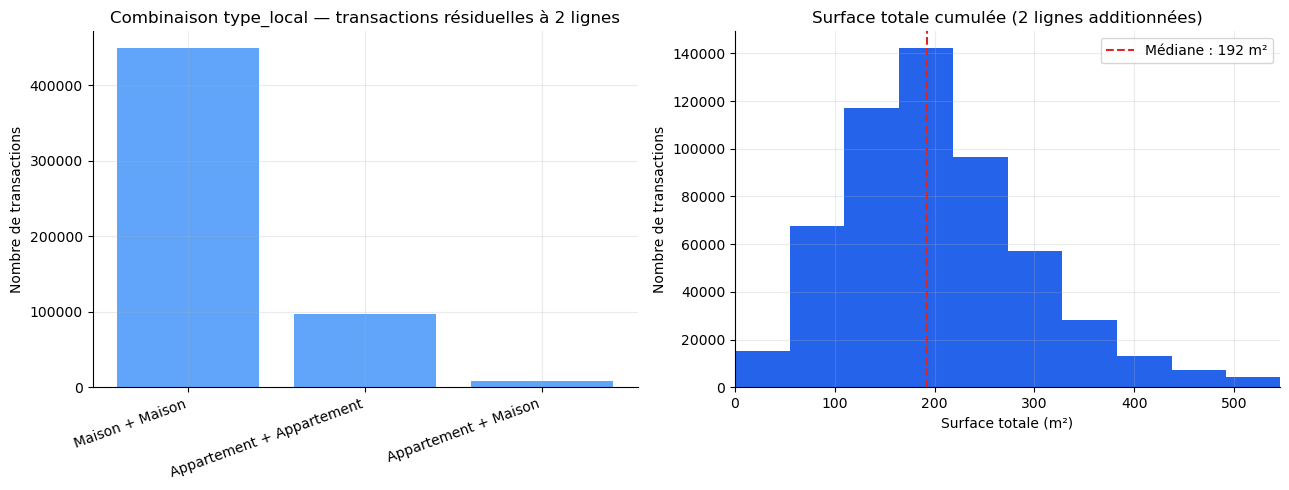

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

combo_counts = candidats_2lignes["combo_types"].value_counts()
combo_labels = [" + ".join(c) for c in combo_counts.index]
axes[0].bar(combo_labels, combo_counts.values, color=COLORS["bleu_secondaire"])
axes[0].set_title("Combinaison type_local \u2014 transactions r\u00e9siduelles \u00e0 2 lignes")
axes[0].set_ylabel("Nombre de transactions")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

surf = candidats_2lignes["surface_totale"].dropna()
axes[1].hist(surf, bins=60, color=COLORS["bleu_primaire"], edgecolor="none")
axes[1].axvline(surf.median(), color=COLORS["rouge_exclusion"], linestyle="--",
                 label=f"M\u00e9diane : {surf.median():.0f} m\u00b2")
axes[1].set_title("Surface totale cumul\u00e9e (2 lignes additionn\u00e9es)")
axes[1].set_xlabel("Surface totale (m\u00b2)")
axes[1].set_ylabel("Nombre de transactions")
axes[1].set_xlim(0, surf.quantile(0.99))
axes[1].legend()

plt.tight_layout()
plt.show()


### Interprétation — composition des transactions résiduelles à 2 lignes

**Résultat obtenu** (553 885 transactions à exactement 2 lignes, sur les 695 857 candidats "vente en bloc" résiduels) :

| Combinaison type_local | Volume | % |
|---|---|---|
| (Maison, Maison) | 448 675 | 81.0% |
| (Appartement, Appartement) | 97 460 | 17.6% |
| (Appartement, Maison) | 7 750 | 1.4% |

Surface totale cumulée (les 2 lignes additionnées) : médiane **192 m²**, 95e percentile 392 m², max 3 280 m².

**Interprétation** : à comparer à la distribution surface_reelle_bati d'une Maison/Appartement individuelle
(Vérification cohérence surface/pièces, plus bas dans ce notebook) : médiane **75 m²** sur le périmètre
complet. Le rapport (192 vs 75, ~2.5x) est trop élevé pour une simple ligne dupliquée ou un même bâtiment
scindé en 2 lots identiques, mais cohérent avec **deux structures distinctes sur une même propriété**
(maison principale + dépendance/atelier codée par erreur en "Maison" au lieu de "Dépendance", ou propriété
à bâtiments multiples — cf. le cas légitime `2021-100003` repéré en Vérification 3). La très forte
dominance des paires homogènes (Maison+Maison, Appartement+Appartement — 98.6% du volume) plutôt que
mixtes va dans le même sens : peu compatible avec une vente en bloc classique d'immeuble (qui mélangerait
plus souvent des Appartements de tailles différentes), plus compatible avec deux bâtiments d'un même bien.

**Règle retenue pour ce sous-cas (2 lignes, valeur identique)** : **agréger** — sommer les surfaces et
garder 1 ligne par id_mutation, plutôt qu'exclure. Le prix (identique sur les 2 lignes, donc déjà le prix
total réel) reste inchangé ; seule la surface doit être recalculée par somme pour un prix/m² cohérent.

**⚠️ Point non résolu** : cette investigation ne couvre que les transactions à **exactement 2 lignes**
(553 885 sur 695 857 candidats résiduels, soit 79.6%). Il reste **141 972 transactions à 3 lignes ou plus**
non encore examinées — c'est probablement dans ce sous-groupe que se trouvent les vraies ventes en bloc
d'immeubles (cf. le cas Paris 16e à 18 lignes, ou les cas à plusieurs milliers de lignes observés en
Vérification 2bis). Voir la cellule d'investigation ajoutée juste en dessous pour trancher ce sous-groupe
avant de figer une règle Talend complète.

## Vérification 5 (suite) — transactions résiduelles à 3 lignes ou plus (141 972 cas)

Complète l'investigation ci-dessus : les 553 885 transactions à exactement 2 lignes ont été tranchées
(agrégation). Reste à examiner les **141 972 transactions à 3 lignes ou plus** (695 857 - 553 885), plus
susceptibles de contenir les vraies ventes en bloc d'immeubles entiers.

In [22]:
# Recharge final_resume_dedup depuis le disque si absent (cf. Vérification 5)
try:
    final_resume_dedup
except NameError:
    final_resume_dedup = pd.read_parquet(FINAL_RESUME_DEDUP_PATH)
    print(f"final_resume_dedup rechargé depuis {FINAL_RESUME_DEDUP_PATH}")

candidats_3plus = final_resume_dedup[
    (final_resume_dedup["nb_lignes"] >= 3) & (final_resume_dedup["valeur_identique"])
].copy()

print(f"Transactions résiduelles à 3 lignes ou plus : {len(candidats_3plus):,}")
print()
print("Distribution du nombre de lignes :")
print(candidats_3plus["nb_lignes"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Répartition en tranches, pour voir si un seuil naturel se dégage (ex: 3-5 lignes vs 50+ lignes)
bins = [3, 5, 10, 20, 50, 100, 500, candidats_3plus["nb_lignes"].max() + 1]
labels = ["3-4", "5-9", "10-19", "20-49", "50-99", "100-499", "500+"]
candidats_3plus["tranche"] = pd.cut(candidats_3plus["nb_lignes"], bins=bins, labels=labels, right=False)
print()
print("Répartition par tranche de nombre de lignes :")
print(candidats_3plus["tranche"].value_counts().sort_index())

Transactions résiduelles à 3 lignes ou plus : 142,578

Distribution du nombre de lignes :
count    142578.000000
mean          4.552631
std          13.907602
min           3.000000
25%           3.000000
50%           3.000000
75%           4.000000
90%           6.000000
95%           9.000000
99%          19.000000
max        2769.000000
Name: nb_lignes, dtype: float64

Répartition par tranche de nombre de lignes :
tranche
3-4        110081
5-9         26764
10-19        4394
20-49        1107
50-99         169
100-499        54
500+            9
Name: count, dtype: int64


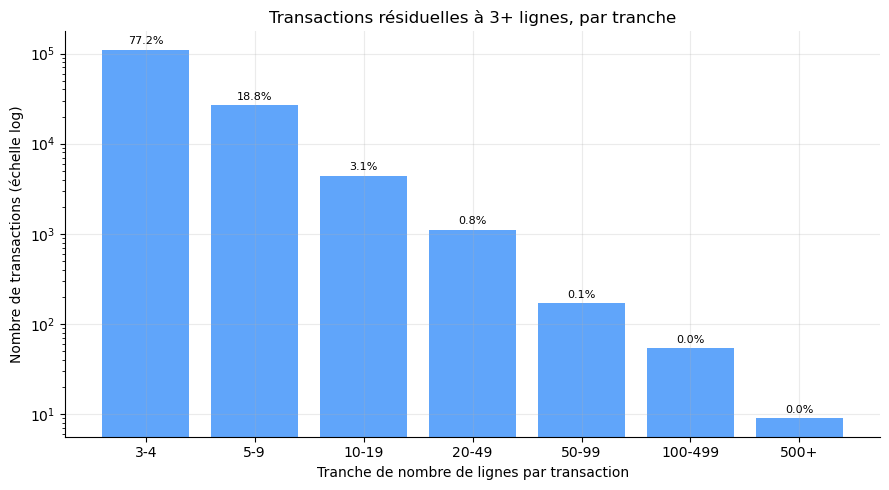

In [23]:
import matplotlib.pyplot as plt

tranche_counts = candidats_3plus["tranche"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tranche_counts.index.astype(str), tranche_counts.values, color=COLORS["bleu_secondaire"])
ax.set_yscale("log")
ax.set_xlabel("Tranche de nombre de lignes par transaction")
ax.set_ylabel("Nombre de transactions (\u00e9chelle log)")
ax.set_title("Transactions r\u00e9siduelles \u00e0 3+ lignes, par tranche")

total = tranche_counts.sum()
for bar, val in zip(bars, tranche_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.15, f"{val / total * 100:.1f}%",
            ha="center", fontsize=8)

plt.tight_layout()
plt.show()


### Interprétation — cas à 3 lignes ou plus

**Résultat obtenu** (142 578 transactions à 3 lignes ou plus) :

| Tranche nb_lignes | Volume | % |
|---|---|---|
| 3-4 | 110 081 | 77.2% |
| 5-9 | 26 764 | 18.8% |
| 10-19 | 4 394 | 3.1% |
| 20-49 | 1 107 | 0.8% |
| 50-99 | 169 | 0.1% |
| 100-499 | 54 | 0.04% |
| 500+ | 9 | 0.006% |

Médiane 3 lignes, 90e percentile 6, 99e percentile 19, max 2 769.

**Interprétation** : 96% du volume (136 845 / 142 578) est concentré sur 3-9 lignes — un prolongement
direct de la population à 2 lignes déjà tranchée (agrégation), qui suit la même logique probable (petites
propriétés à plusieurs bâtiments : maison + dépendance(s) mal codée(s), ou lots cadastraux scindés). La
queue de distribution (50+ lignes, 232 transactions, 0.16%) correspond très probablement aux vraies ventes
en bloc d'immeubles (cohérent avec le cas Paris 16e à 18 lignes et le cas à 8 058 lignes déjà repérés en
Vérification 2bis).

**⚠️ Cette lecture reste une hypothèse basée sur la seule distribution du nombre de lignes** — elle n'a pas
encore été confirmée par un examen de composition (`type_local`) et de surface cumulée, contrairement au
cas à 2 lignes où cet examen a été fait. Cellule d'investigation ajoutée ci-dessous pour combler ce point
avant de figer un seuil définitif.

## Vérification 5 (fin) — composition des transactions à 3+ lignes, par tranche

Même logique que pour le cas à 2 lignes : examiner la composition `type_local` et la surface cumulée,
mais cette fois **segmentée par tranche de nb_lignes**, pour confirmer (ou infirmer) l'hypothèse d'un seuil
naturel autour de 9-10 lignes entre "petite propriété multi-bâtiments" et "vraie vente en bloc".

In [24]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "id_mutation", "valeur_fonciere", "surface_reelle_bati"]

try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)

resume_types_3plus = []
global_idx = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]
    chunk_dedup = chunk[chunk_keep_mask]
    global_idx += n

    subset = chunk_dedup[
        (chunk_dedup["nature_mutation"] == "Vente") &
        (chunk_dedup["type_local"].isin(["Maison", "Appartement"]))
    ]
    if len(subset) > 0:
        g = subset.groupby("id_mutation").agg(
            nb_lignes=("valeur_fonciere", "size"),
            types=("type_local", lambda x: tuple(sorted(x))),
            surface_totale=("surface_reelle_bati", "sum"),
        )
        resume_types_3plus.append(g)

all_types_3plus = pd.concat(resume_types_3plus)
final_types_3plus = all_types_3plus.groupby("id_mutation").agg(
    nb_lignes=("nb_lignes", "sum"),
    types=("types", "sum"),
    surface_totale=("surface_totale", "sum"),
)

candidats_3plus_detail = final_types_3plus[final_types_3plus["nb_lignes"] >= 3].copy()
candidats_3plus_detail["homogene"] = candidats_3plus_detail["types"].apply(lambda t: len(set(t)) == 1)

bins = [3, 5, 10, 20, 50, 100, 500, candidats_3plus_detail["nb_lignes"].max() + 1]
labels = ["3-4", "5-9", "10-19", "20-49", "50-99", "100-499", "500+"]
candidats_3plus_detail["tranche"] = pd.cut(candidats_3plus_detail["nb_lignes"], bins=bins, labels=labels, right=False)

print("Part de transactions HOMOGÈNES (toutes les lignes du même type_local) par tranche :")
print(candidats_3plus_detail.groupby("tranche", observed=True)["homogene"].mean())
print()
print("Surface totale cumulée médiane par tranche :")
print(candidats_3plus_detail.groupby("tranche", observed=True)["surface_totale"].median())
print()
print("Surface totale cumulée MOYENNE par tranche (plus sensible aux gros volumes type immeuble) :")
print(candidats_3plus_detail.groupby("tranche", observed=True)["surface_totale"].mean())

Part de transactions HOMOGÈNES (toutes les lignes du même type_local) par tranche :
tranche
3-4        0.937325
5-9        0.883517
10-19      0.860759
20-49      0.819277
50-99      0.755556
100-499    0.475410
500+       0.090909
Name: homogene, dtype: float64

Surface totale cumulée médiane par tranche :
tranche
3-4          241.0
5-9          328.0
10-19        720.0
20-49       1647.5
50-99       4088.5
100-499    10335.0
500+       86529.0
Name: surface_totale, dtype: float64

Surface totale cumulée MOYENNE par tranche (plus sensible aux gros volumes type immeuble) :
tranche
3-4          283.001683
5-9          406.441370
10-19        829.438374
20-49       1887.709983
50-99       4320.255556
100-499    11801.639344
500+       97922.272727
Name: surface_totale, dtype: float64


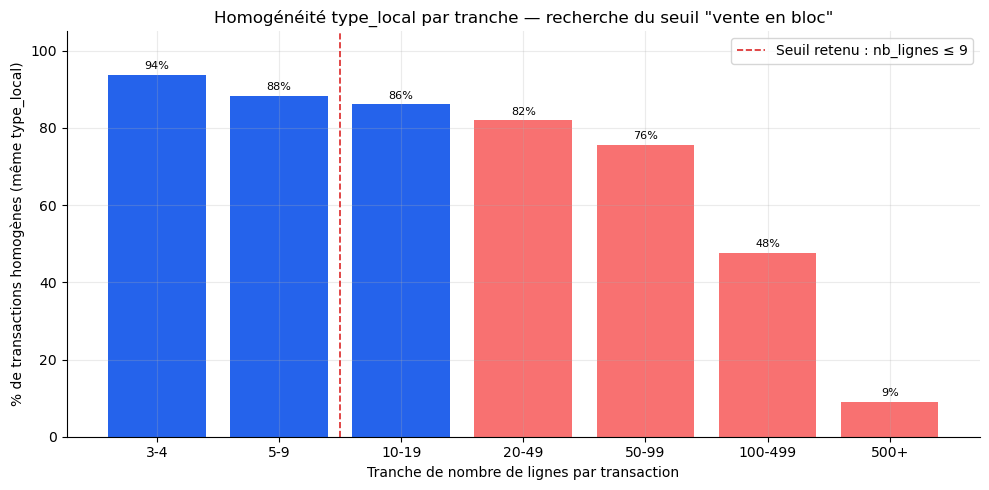

In [25]:
import matplotlib.pyplot as plt

homogeneite = candidats_3plus_detail.groupby("tranche", observed=True)["homogene"].mean() * 100
bar_colors = [COLORS["bleu_primaire"] if v >= 85 else COLORS["rouge_modere"] for v in homogeneite.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(homogeneite.index.astype(str), homogeneite.values, color=bar_colors)
ax.set_ylabel("% de transactions homog\u00e8nes (m\u00eame type_local)")
ax.set_xlabel("Tranche de nombre de lignes par transaction")
ax.set_title('Homog\u00e9n\u00e9it\u00e9 type_local par tranche \u2014 recherche du seuil "vente en bloc"')
ax.set_ylim(0, 105)

seuil_idx = list(homogeneite.index).index("5-9") + 0.5
ax.axvline(seuil_idx, color=COLORS["rouge_exclusion"], linestyle="--", linewidth=1.2,
           label="Seuil retenu : nb_lignes \u2264 9")
ax.legend()

for bar, val in zip(bars, homogeneite.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.0f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


### Interprétation — composition par tranche

**Résultat obtenu** :

| Tranche | Homogène | Surface médiane | Surface/ligne implicite |
|---|---|---|---|
| 3-4 | 93.7% | 241 m² | ~69 m² |
| 5-9 | 88.4% | 328 m² | ~47 m² |
| 10-19 | 86.1% | 720 m² | ~50 m² |
| 20-49 | 81.9% | 1 648 m² | ~48 m² |
| 50-99 | 75.6% | 4 089 m² | ~54 m² |
| 100-499 | 47.5% | 10 335 m² | ~34 m² |
| 500+ | 9.1% | 86 529 m² | ~86 m² |

**Interprétation** : contrairement à l'attente, la **surface cumulée ne fournit pas de rupture nette** —
elle croît quasi proportionnellement au nombre de lignes, avec une surface implicite par ligne qui reste
dans un ordre de grandeur plausible (35-70 m²/ligne) sur **toutes** les tranches, y compris les plus
grosses. Ça n'est pas un signal utilisable seul pour distinguer "propriété avec annexes" de "vrai immeuble" :
un immeuble de 50 appartements de 50 m² chacun produit exactement le même ratio qu'une petite propriété à
quelques dépendances.

Le vrai signal discriminant est l'**homogénéité `type_local`** : elle reste élevée (>85%) jusqu'à la tranche
10-19, décroît progressivement (81.9% puis 75.6%), puis **chute nettement** à partir de 100 lignes
(47.5%, puis 9.1% pour 500+). Cette chute est cohérente avec de vrais ensembles immobiliers mixtes
(logements + commerces, ou copropriétés hétérogènes) — le genre de composition qu'on n'attend pas d'une
propriété individuelle avec annexes.

**Constat honnête** : il n'y a **pas de seuil unique évident** dans les données — la transition est
progressive, pas une rupture franche. La décision reste in fine un arbitrage, pas une certitude
mathématique.

**Règle Talend retenue et FINALISÉE** : `nb_lignes <= 9` → agréger ; `nb_lignes > 9` → exclure comme vente
en bloc. Justification du seuil à 9 (plutôt que 19 ou 49, également défendables) : c'est là que
l'homogénéité est encore >85% ET que le volume concerné reste minoritaire dans la traîne (136 845
transactions sur 142 578, 96%) — un seuil plus haut inclurait de plus en plus de cas où le doute
s'installe sans gain de volume significatif. **Limite assumée** : ce choix n'élimine pas complètement le
risque de contamination croisée (probablement quelques centaines à quelques milliers de "vrais petits
immeubles" agrégés à tort dans la tranche 3-9, et à l'inverse quelques grandes propriétés légitimes
exclues à tort au-delà de 9) — impact résiduel jugé négligeable au vu du volume total du dataset (5,9M
transactions).

## Vérification 6 — transactions multi-lignes à valeur_fonciere DIFFÉRENTE (cas résiduel, 1 469)

Reste un troisième cas de figure, mentionné plusieurs fois comme "à examiner séparément" mais jamais
traité jusqu'ici : les transactions multi-lignes dont `valeur_fonciere` **diffère** entre les lignes
(1 469 sur 4 732 172, après dédoublonnage — cf. Vérification 5). Contrairement aux "ventes en bloc"
(valeur identique répétée), une valeur différente par ligne pourrait indiquer une **répartition légitime
du prix total par lot** (ex : prix affecté ligne par ligne à chaque lot d'une même transaction) plutôt
qu'une anomalie.

Population très petite (1 469 transactions) : on peut les examiner **intégralement**, pas seulement un
échantillon — cohérent avec la préférence déjà appliquée ailleurs dans ce notebook, et avec la leçon tirée
de l'échantillon de 5 cas non représentatif en Vérification 5.

In [26]:
# Recharge final_resume_dedup depuis le disque si cette cellule est exécutée dans une nouvelle session
# (cf. cellule de sauvegarde en Vérification 5)
try:
    final_resume_dedup
except NameError:
    final_resume_dedup = pd.read_parquet(FINAL_RESUME_DEDUP_PATH)
    print(f"final_resume_dedup rechargé depuis {FINAL_RESUME_DEDUP_PATH}")

# Réutilise `final_resume_dedup`, déjà calculé en Vérification 5 (cellule ci-dessus), toujours en mémoire
cas_valeur_differente = final_resume_dedup[
    (final_resume_dedup["nb_lignes"] > 1) & (~final_resume_dedup["valeur_identique"])
].copy()

print(f"Transactions multi-lignes à valeur différente : {len(cas_valeur_differente):,}")
print()
print("Distribution du nombre de lignes par transaction :")
print(cas_valeur_differente["nb_lignes"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

# Écart relatif entre la valeur la plus basse et la plus haute de la transaction :
# un petit écart évoque une variation de prix par lot cohérente, un écart énorme évoque une erreur de saisie
cas_valeur_differente["ecart_pct"] = (
    (cas_valeur_differente["max_val"] - cas_valeur_differente["min_val"])
    / cas_valeur_differente["min_val"] * 100
)
print()
print("Écart relatif (max_val - min_val) / min_val, en % :")
print(cas_valeur_differente["ecart_pct"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

Transactions multi-lignes à valeur différente : 1,469

Distribution du nombre de lignes par transaction :
count    1469.000000
mean        9.093941
std        75.248566
min         2.000000
25%         2.000000
50%         3.000000
75%         6.000000
95%        20.000000
99%        55.000000
max      2400.000000
Name: nb_lignes, dtype: float64

Écart relatif (max_val - min_val) / min_val, en % :
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
95%      NaN
99%      NaN
max      NaN
Name: ecart_pct, dtype: float64


In [27]:
# Recharge keep_mask depuis le disque si cette cellule est exécutée dans une nouvelle session de kernel
# (ex: reprise du notebook sans tout relancer depuis le début — cf. cellule de sauvegarde en Vérification 5)
try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)
    print(f"keep_mask rechargé depuis {KEEP_MASK_PATH}")

# Population assez petite (1 469) pour récupérer TOUTES les lignes concernées, pas un échantillon
ids_valeur_differente = set(cas_valeur_differente.index)

cols_needed_detail = ["id_mutation", "type_local", "valeur_fonciere",
                       "surface_reelle_bati", "nombre_pieces_principales"]
lignes_valeur_differente = []
global_idx = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed_detail, chunksize=1_000_000, low_memory=False):
    n = len(chunk)
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]  # dédoublonnage, cf. Vérification 5
    global_idx += n
    chunk_dedup = chunk[chunk_keep_mask]

    match = chunk_dedup[chunk_dedup["id_mutation"].isin(ids_valeur_differente)]
    if len(match) > 0:
        lignes_valeur_differente.append(match)

df_valeur_differente = pd.concat(lignes_valeur_differente).sort_values(["id_mutation", "valeur_fonciere"])
print(f"Lignes récupérées : {len(df_valeur_differente):,} pour "
      f"{df_valeur_differente['id_mutation'].nunique():,} transactions")

# Si c'est une répartition légitime du prix par lot, la SOMME des valeur_fonciere par transaction
# devrait ressembler à un prix de bien individuel plausible (comparer à la médiane Vérification 2 :
# ~210 000€ Maison / ~189 000€ Appartement)
somme_par_transaction = df_valeur_differente.groupby("id_mutation")["valeur_fonciere"].sum()
print()
print("Distribution de la SOMME des valeur_fonciere par transaction :")
print(somme_par_transaction.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

Lignes récupérées : 41,772 pour 1,469 transactions

Distribution de la SOMME des valeur_fonciere par transaction :
count    1469.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
95%         0.0
99%         0.0
max         0.0
Name: valeur_fonciere, dtype: float64


### Interprétation — transactions à valeur différente

**⚠️ Grille de lecture obsolète** — les résultats obtenus (`ecart_pct` et somme `valeur_fonciere` tous à
NaN/0) ont révélé un bug de fond plutôt qu'un vrai phénomène de prix réparti par lot. Voir le diagnostic et
la version corrigée juste en dessous.

### ⚠️ Bug méthodologique repéré — la catégorie "valeur différente" est un artefact

Les résultats obtenus ci-dessus sont anormaux : `ecart_pct` est NaN pour les 1 469 transactions
(`count = 0` dans le `.describe()`), et la somme de `valeur_fonciere` par transaction est exactement
**0.0** pour les 1 469 également. Ce n'est pas un hasard — c'est un bug de comparaison avec les valeurs
manquantes, présent depuis la toute première version de la règle (cellule "Application de la règle vente
en bloc à l'ensemble du dataset", et reprise à l'identique en Vérification 5) :

```python
final_resume_dedup["valeur_identique"] = final_resume_dedup["min_val"] == final_resume_dedup["max_val"]
```

En Python/pandas, `NaN == NaN` renvoie **False**, jamais True. Donc une transaction dont `valeur_fonciere`
est manquante sur **toutes** ses lignes Maison/Appartement obtient `min_val = NaN` et `max_val = NaN`, et
`valeur_identique` devient **False** — elle est alors classée à tort dans "valeur différente" alors qu'en
réalité, il n'y a tout simplement **aucune donnée de prix disponible**, pas une différence de prix réelle.

Ça n'affecte **pas** les chiffres déjà actés sur la "vente en bloc" (711 054 / 695 857) : `valeur_identique`
ne peut être `True` que si les deux valeurs sont réellement égales et non manquantes — un groupe entièrement
`NaN` ne peut donc jamais tomber dans ce panier-là, seulement dans "valeur différente". Seule cette dernière
catégorie (1 509 avant dédup, 1 469 après) est concernée.

In [28]:
# Recharge final_resume_dedup si absent
try:
    final_resume_dedup
except NameError:
    final_resume_dedup = pd.read_parquet(FINAL_RESUME_DEDUP_PATH)

cas_valeur_differente = final_resume_dedup[
    (final_resume_dedup["nb_lignes"] > 1) & (~final_resume_dedup["valeur_identique"])
].copy()

# Vérification directe de l'hypothèse : combien de ces transactions ont min_val/max_val manquants ?
nb_prix_manquant = cas_valeur_differente["min_val"].isna().sum()
nb_prix_reellement_different = len(cas_valeur_differente) - nb_prix_manquant

print(f"Transactions classées 'valeur différente' : {len(cas_valeur_differente):,}")
print(f"  dont valeur_fonciere manquante sur toutes les lignes (artefact du bug) : {nb_prix_manquant:,}")
print(f"  dont un vrai écart de prix entre lignes (cas réel) : {nb_prix_reellement_different:,}")

# Recalcul propre de l'écart relatif, seulement sur les cas où le prix est réellement connu
cas_prix_reel = cas_valeur_differente[cas_valeur_differente["min_val"].notna()].copy()
if len(cas_prix_reel) > 0:
    cas_prix_reel["ecart_pct"] = (
        (cas_prix_reel["max_val"] - cas_prix_reel["min_val"]) / cas_prix_reel["min_val"] * 100
    )
    print()
    print("Écart relatif (max_val - min_val) / min_val, en % — sur les cas à prix réellement différent :")
    print(cas_prix_reel["ecart_pct"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
else:
    print()
    print("Aucun cas à prix réellement différent — la catégorie était 100% un artefact du bug NaN.")

Transactions classées 'valeur différente' : 1,469
  dont valeur_fonciere manquante sur toutes les lignes (artefact du bug) : 1,469
  dont un vrai écart de prix entre lignes (cas réel) : 0

Aucun cas à prix réellement différent — la catégorie était 100% un artefact du bug NaN.


### Interprétation — bug corrigé

**Résultat obtenu — hypothèse confirmée à 100%** :

```
Transactions classées 'valeur différente' : 1 469
  dont valeur_fonciere manquante sur toutes les lignes (artefact du bug) : 1 469
  dont un vrai écart de prix entre lignes (cas réel) : 0
```

**Interprétation** : confirmation totale — les 1 469 transactions étaient **intégralement** un artefact du
bug `NaN == NaN`. Il n'existe **aucun** cas réel de "prix réparti différemment par ligne" dans tout le
dataset résidentiel dédupliqué. La catégorie "valeur différente" peut être définitivement écartée de
l'analyse.

**Règle Talend : AUCUNE RÈGLE SPÉCIFIQUE À ÉCRIRE.** Ces 1 469 transactions sont déjà couvertes par la
règle générique "lignes sans `valeur_fonciere` → exclure", actée depuis le tout début du projet. Point
définitivement clos.

**Point méthodologique pour la Phase 2 (Talend)** : ce bug illustre pourquoi les comparaisons d'égalité sur
des colonnes pouvant contenir des NaN doivent systématiquement être doublées d'un test de complétude
(`notna()`) — autant dans du code Python que dans les règles Talend (une transformation qui compare deux
valeurs manquantes ne doit pas être traitée comme "différentes", mais comme "donnée absente").

## Vérification géographique — plausibilité longitude/latitude

Objectif : repérer les coordonnées manifestement fausses (0,0, hors de tout territoire français) avant de les utiliser pour du reverse-geocoding ou de la cartographie en Phase 2/3. On distingue explicitement la France métropolitaine des DOM-TOM (codes département 971-976) pour ne pas exclure à tort des lignes légitimes hors métropole.

In [29]:
CHUNK_SIZE = 1_000_000
cols_needed = ["longitude", "latitude", "code_departement"]

# Bornes larges couvrant la France métropolitaine + Corse (avec marge de sécurité)
LON_MIN, LON_MAX = -5.5, 10.0
LAT_MIN, LAT_MAX = 41.0, 51.5
DOM_CODES = {"971", "972", "973", "974", "975", "976"}

total_avec_coord = 0
zero_zero = 0
hors_bornes_hors_dom = 0
hors_bornes_dom = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    coord = chunk.dropna(subset=["longitude", "latitude"])
    total_avec_coord += len(coord)

    is_zero = (coord["longitude"] == 0) & (coord["latitude"] == 0)
    zero_zero += is_zero.sum()

    hors = ~coord["longitude"].between(LON_MIN, LON_MAX) | ~coord["latitude"].between(LAT_MIN, LAT_MAX)
    is_dom = coord["code_departement"].astype(str).isin(DOM_CODES)

    hors_bornes_dom += (hors & is_dom).sum()
    hors_bornes_hors_dom += (hors & ~is_dom).sum()

print(f"Lignes avec longitude/latitude renseignées : {total_avec_coord:,}")
print(f"Coordonnées (0,0) suspectes : {zero_zero:,} ({zero_zero/total_avec_coord*100:.3f}%)")
print(f"Hors bornes métropole, code_departement DOM-TOM (971-976) → attendu, à garder : {hors_bornes_dom:,}")
print(f"Hors bornes métropole, code_departement NON-DOM → probable erreur, à exclure : {hors_bornes_hors_dom:,} "
      f"({hors_bornes_hors_dom/total_avec_coord*100:.3f}%)")

Lignes avec longitude/latitude renseignées : 19,954,941
Coordonnées (0,0) suspectes : 0 (0.000%)
Hors bornes métropole, code_departement DOM-TOM (971-976) → attendu, à garder : 194,273
Hors bornes métropole, code_departement NON-DOM → probable erreur, à exclure : 334 (0.002%)


In [30]:
import matplotlib.pyplot as plt

plausible = total_avec_coord - zero_zero - hors_bornes_dom - hors_bornes_hors_dom

categories = ["Coordonn\u00e9es plausibles\n(m\u00e9tropole)", "Hors bornes\nDOM-TOM (attendu)",
              "Coordonn\u00e9es (0,0)\nsuspectes", "Hors bornes\nhors DOM-TOM (erreur)"]
valeurs = [plausible, hors_bornes_dom, zero_zero, hors_bornes_hors_dom]
colors = [COLORS["bleu_marine"], COLORS["bleu_secondaire"], COLORS["rouge_modere"], COLORS["rouge_critique"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(categories, valeurs, color=colors)
ax.set_yscale("log")
ax.set_ylabel("Nombre de lignes (\u00e9chelle log)")
ax.set_title("Plausibilit\u00e9 g\u00e9ographique des coordonn\u00e9es longitude/latitude")

for i, val in enumerate(valeurs):
    ax.text(i, val * 1.3, f"{val:,}\n({val / total_avec_coord * 100:.3f}%)", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


C:\Users\eree\AppData\Local\Temp\ipykernel_2908\1116916095.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


### Interprétation — plausibilité géographique

**Résultat obtenu** :

| | Valeur |
|---|---|
| Lignes avec longitude/latitude renseignées | 19 954 941 |
| Coordonnées (0,0) suspectes | 0 |
| Hors bornes métropole, DOM-TOM (971-976) — attendu, à garder | 194 273 |
| Hors bornes métropole, NON-DOM — probable erreur, à exclure | 334 (0.002%) |

**Interprétation** : résultat conforme aux attentes, aucun retraitement supplémentaire nécessaire sur ce point.
- Aucune coordonnée `(0,0)` — pas de nettoyage supplémentaire nécessaire sur ce point.
- Les 194 273 lignes hors bornes métropole sont bien des DOM-TOM légitimes (code_departement 971-976),
  cohérent avec le fait que le dataset DVF géolocalisé couvre la France entière.
- Seulement 334 lignes (0.002% des lignes géolocalisées) sont hors bornes ET hors DOM-TOM → vraies erreurs
  de coordonnées, volumétrie négligeable.

**Règle Talend retenue** : la règle déjà actée ("exclure les lignes sans longitude/latitude") reste
suffisante. Ajouter en complément une exclusion explicite des 334 lignes hors bornes géographiques
(hors métropole ET hors DOM-TOM) — volumétrie marginale mais protège contre des points aberrants sur la
carte Power BI (Phase 3).

## Vérification cohérence surface_reelle_bati / nombre_pieces_principales

Objectif : repérer les valeurs aberrantes (surface à 0 m² pour un bien vendu, nombre de pièces à 0, surfaces extrêmes) sur le périmètre résidentiel filtré (Maison/Appartement, Vente).

In [31]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "surface_reelle_bati", "nombre_pieces_principales"]

stats = {"total": 0, "surface_manquante": 0, "surface_zero": 0, "pieces_manquantes": 0, "pieces_zero": 0}
surfaces = []
pieces = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    ventes = chunk[
        (chunk["nature_mutation"] == "Vente") &
        (chunk["type_local"].isin(["Maison", "Appartement"]))
    ]
    stats["total"] += len(ventes)
    stats["surface_manquante"] += ventes["surface_reelle_bati"].isna().sum()
    stats["surface_zero"] += (ventes["surface_reelle_bati"] == 0).sum()
    stats["pieces_manquantes"] += ventes["nombre_pieces_principales"].isna().sum()
    stats["pieces_zero"] += (ventes["nombre_pieces_principales"] == 0).sum()

    surfaces.append(ventes["surface_reelle_bati"].dropna())
    pieces.append(ventes["nombre_pieces_principales"].dropna())

surface_series = pd.concat(surfaces)
pieces_series = pd.concat(pieces)

print(f"Total lignes Maison/Appartement (Vente) : {stats['total']:,}")
print(f"surface_reelle_bati manquante : {stats['surface_manquante']:,} ({stats['surface_manquante']/stats['total']*100:.2f}%)")
print(f"surface_reelle_bati == 0 : {stats['surface_zero']:,} ({stats['surface_zero']/stats['total']*100:.3f}%)")
print(f"nombre_pieces_principales manquant : {stats['pieces_manquantes']:,} ({stats['pieces_manquantes']/stats['total']*100:.2f}%)")
print(f"nombre_pieces_principales == 0 : {stats['pieces_zero']:,} ({stats['pieces_zero']/stats['total']*100:.3f}%)")
print()
print("Distribution surface_reelle_bati (hors NaN) :")
print(surface_series.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print()
print("Distribution nombre_pieces_principales (hors NaN) :")
print(pieces_series.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

Total lignes Maison/Appartement (Vente) : 6,080,977
surface_reelle_bati manquante : 544 (0.01%)
surface_reelle_bati == 0 : 0 (0.000%)
nombre_pieces_principales manquant : 542 (0.01%)
nombre_pieces_principales == 0 : 11,821 (0.194%)

Distribution surface_reelle_bati (hors NaN) :
count    6.080433e+06
mean     8.192983e+01
std      4.661387e+01
min      1.000000e+00
1%       1.500000e+01
5%       2.400000e+01
50%      7.500000e+01
95%      1.630000e+02
99%      2.390000e+02
max      3.160000e+03
Name: surface_reelle_bati, dtype: float64

Distribution nombre_pieces_principales (hors NaN) :
count    6.080435e+06
mean     3.462547e+00
std      1.613232e+00
min      0.000000e+00
1%       1.000000e+00
5%       1.000000e+00
50%      3.000000e+00
95%      6.000000e+00
99%      8.000000e+00
max      1.980000e+02
Name: nombre_pieces_principales, dtype: float64


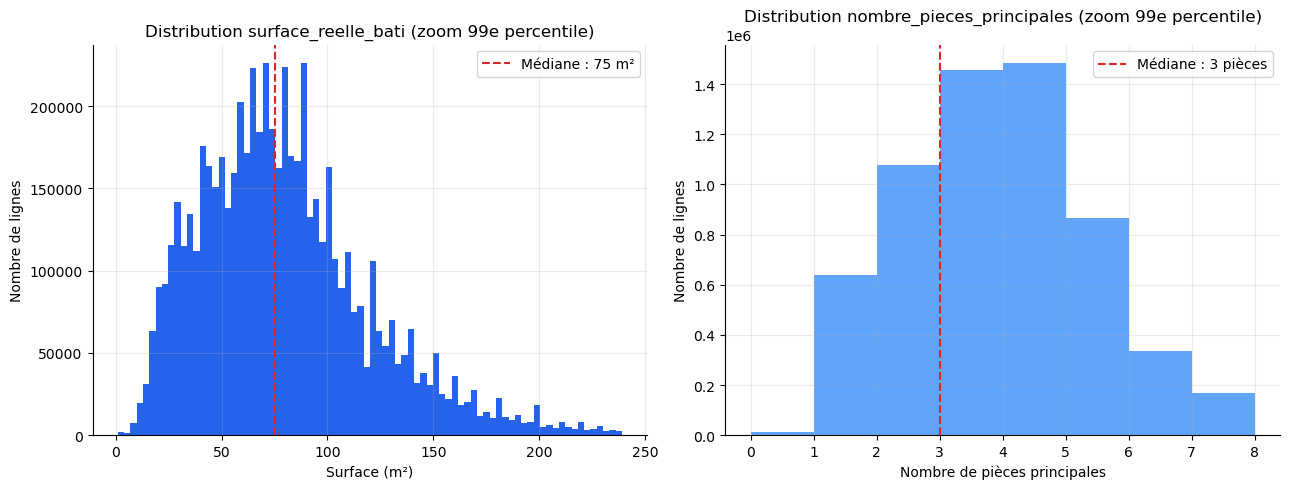

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

surf_zoom = surface_series[surface_series <= surface_series.quantile(0.99)]
axes[0].hist(surf_zoom, bins=80, color=COLORS["bleu_primaire"], edgecolor="none")
axes[0].axvline(surface_series.median(), color=COLORS["rouge_exclusion"], linestyle="--",
                 label=f"M\u00e9diane : {surface_series.median():.0f} m\u00b2")
axes[0].set_title("Distribution surface_reelle_bati (zoom 99e percentile)")
axes[0].set_xlabel("Surface (m\u00b2)")
axes[0].set_ylabel("Nombre de lignes")
axes[0].legend()

pieces_zoom = pieces_series[pieces_series <= pieces_series.quantile(0.99)]
axes[1].hist(pieces_zoom, bins=max(int(pieces_zoom.max()), 1), color=COLORS["bleu_secondaire"], edgecolor="none")
axes[1].axvline(pieces_series.median(), color=COLORS["rouge_exclusion"], linestyle="--",
                 label=f"M\u00e9diane : {pieces_series.median():.0f} pi\u00e8ces")
axes[1].set_title("Distribution nombre_pieces_principales (zoom 99e percentile)")
axes[1].set_xlabel("Nombre de pi\u00e8ces principales")
axes[1].set_ylabel("Nombre de lignes")
axes[1].legend()

plt.tight_layout()
plt.show()


### Interprétation — cohérence surface / pièces

**Résultat obtenu** (6 080 977 lignes Maison/Appartement en Vente, données brutes non dédupliquées) :

| | Valeur |
|---|---|
| surface_reelle_bati manquante | 544 (0.01%) |
| surface_reelle_bati == 0 | 0 (0.000%) |
| nombre_pieces_principales manquant | 542 (0.01%) |
| nombre_pieces_principales == 0 | 11 821 (0.194%) |

Distribution surface_reelle_bati : médiane 75 m², 95e percentile 163 m², 99e percentile 239 m², max 3 160 m².
Distribution nombre_pieces_principales : médiane 3, 95e percentile 6, 99e percentile 8, **max 198**.

**Interprétation** :
- surface_reelle_bati est quasiment toujours renseignée et cohérente sur ce périmètre (0.01% manquant,
  aucune valeur à 0) — pas de nettoyage nécessaire sur ce point, confirme la fiabilité déjà pressentie de
  cette colonne pour Maison/Appartement.
- nombre_pieces_principales == 0 concerne 11 821 lignes (0.19%) — volumétrie faible mais non nulle,
  plausible en partie (ateliers, lofts ouverts sans pièces cloisonnées déclarées) mais à surveiller.
- **⚠️ Anomalie repérée** : `nombre_pieces_principales` max = **198** — clairement aberrant pour un logement
  individuel (Maison/Appartement). Ce n'était pas anticipé dans la grille de lecture initiale et mérite une
  vérification dédiée avant de figer un seuil haut (cf. cellule ajoutée ci-dessous).

**Règle Talend retenue à ce stade** : garder `surface_reelle_bati` telle quelle (fiable). Pour
`nombre_pieces_principales`, définir un seuil haut réaliste (ex : exclure > 20 pièces pour un logement
individuel) une fois la cause des valeurs extrêmes comprise — voir investigation ci-dessous.

## Vérification cohérence surface / pièces (suite) — anomalie nombre_pieces_principales

Le résultat ci-dessus a fait remonter un `nombre_pieces_principales` max = 198, pas anticipé initialement.
Avant de fixer un seuil haut, on examine cette queue de distribution en détail — combien de lignes sont
concernées, et à quoi ressemble leur surface associée (une valeur aberrante en pièces avec une surface
normale serait une vraie erreur de saisie ; une surface également très élevée pourrait indiquer un vrai
bâtiment atypique, ex: immeuble collectif mal classé).

In [33]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "surface_reelle_bati", "nombre_pieces_principales"]

SEUIL_SUSPECT = 20  # pièces principales — au-delà, peu plausible pour un logement individuel

lignes_suspectes = []

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    ventes = chunk[
        (chunk["nature_mutation"] == "Vente") &
        (chunk["type_local"].isin(["Maison", "Appartement"])) &
        (chunk["nombre_pieces_principales"] > SEUIL_SUSPECT)
    ]
    if len(ventes) > 0:
        lignes_suspectes.append(ventes)

df_suspect = pd.concat(lignes_suspectes) if lignes_suspectes else pd.DataFrame()
print(f"Lignes avec nombre_pieces_principales > {SEUIL_SUSPECT} : {len(df_suspect):,}")
print()
if len(df_suspect) > 0:
    print("Répartition par type_local :")
    print(df_suspect["type_local"].value_counts())
    print()
    print("nombre_pieces_principales vs surface_reelle_bati (ratio m²/pièce, pour juger la plausibilité) :")
    df_suspect["m2_par_piece"] = df_suspect["surface_reelle_bati"] / df_suspect["nombre_pieces_principales"]
    print(df_suspect[["nombre_pieces_principales", "surface_reelle_bati", "m2_par_piece"]]
          .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

Lignes avec nombre_pieces_principales > 20 : 394

Répartition par type_local :
type_local
Maison         323
Appartement     71
Name: count, dtype: int64

nombre_pieces_principales vs surface_reelle_bati (ratio m²/pièce, pour juger la plausibilité) :
       nombre_pieces_principales  surface_reelle_bati  m2_par_piece
count                 394.000000           394.000000    394.000000
mean                   33.903553           223.753807      8.517345
std                    18.004971           326.153202     13.529224
min                    21.000000             8.000000      0.380952
25%                    23.000000            73.000000      2.122727
50%                    27.000000           100.000000      3.380952
75%                    35.000000           159.500000      5.612903
95%                    71.700000           881.000000     40.952381
99%                    95.000000          1538.680000     57.142857
max                   198.000000          2033.000000     72.259259


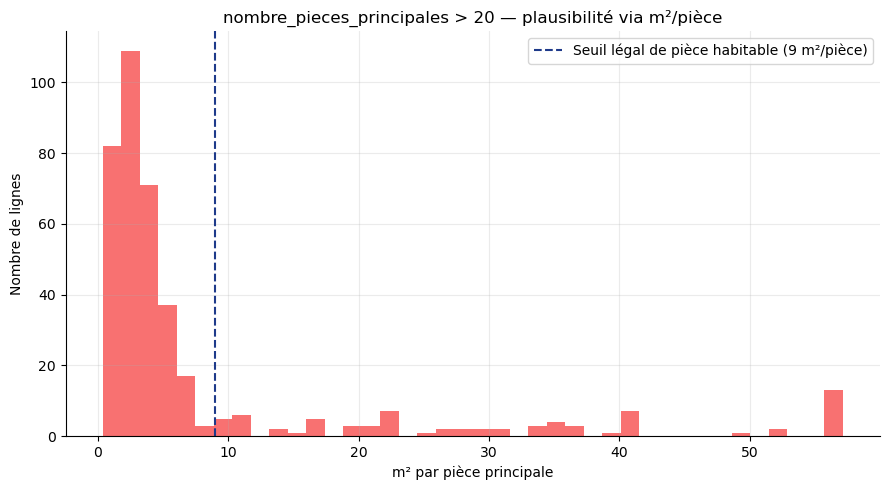

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
m2_clip = df_suspect["m2_par_piece"].clip(upper=df_suspect["m2_par_piece"].quantile(0.99))
ax.hist(m2_clip, bins=40, color=COLORS["rouge_modere"], edgecolor="none")
ax.axvline(9, color=COLORS["bleu_marine"], linestyle="--", linewidth=1.5,
           label="Seuil l\u00e9gal de pi\u00e8ce habitable (9 m\u00b2/pi\u00e8ce)")
ax.set_xlabel("m\u00b2 par pi\u00e8ce principale")
ax.set_ylabel("Nombre de lignes")
ax.set_title("nombre_pieces_principales > 20 \u2014 plausibilit\u00e9 via m\u00b2/pi\u00e8ce")
ax.legend()
plt.tight_layout()
plt.show()


### Interprétation — anomalie nombre_pieces_principales

**Résultat obtenu** (394 lignes avec nombre_pieces_principales > 20, sur 6 080 977 lignes du périmètre —
volumétrie négligeable, 0.006%) :

| | Valeur |
|---|---|
| Répartition type_local | Maison 323 (82%), Appartement 71 (18%) |
| m²/pièce — médiane | 3.38 |
| m²/pièce — 75e percentile | 5.61 |
| m²/pièce — 95e percentile | 40.95 |
| m²/pièce — 99e percentile | 57.14 |

**Interprétation** : la loi française (décret décence, critère RSA/logement décent) fixe un minimum de
**9 m² par pièce principale** pour qu'une pièce soit habitable. Or la **médiane** de ce sous-groupe est à
3.38 m²/pièce — 3 fois sous ce seuil légal — ce qui indique que pour la **majorité** de ces 394 cas,
`nombre_pieces_principales` est very probablement une erreur de saisie (valeur démesurée pour la surface
réelle du bien), pas un vrai décompte de pièces. Seule la queue haute (95e/99e percentile, 41-57 m²/pièce)
est compatible avec de vraies grandes propriétés.

**Règle Talend retenue** : `nombre_pieces_principales > 20 ET surface_reelle_bati / nombre_pieces_principales < 9`
→ exclure du périmètre (erreur de saisie confirmée par le critère légal de pièce habitable). Les rares cas
au-dessus de 9 m²/pièce peuvent être conservés tels quels (grandes propriétés plausibles). Volumétrie de
toute façon marginale (<400 lignes sur 6M), impact négligeable sur les statistiques déjà calculées.

## Formalisation de la règle VEFA

La décision de principe ("garder VEFA séparément comme variable, pas l'exclure") avait été actée mais
jamais implémentée concrètement. En reprenant la répartition de `nature_mutation` (section 4) :

| nature_mutation | lignes |
|---|---|
| Vente | 18 982 926 |
| Vente en l'état futur d'achèvement (VEFA) | 1 046 189 |
| Vente terrain à bâtir | 54 555 |
| Echange / Adjudication / Expropriation | ~299 245 |

**⚠️ Incohérence repérée entre la décision et l'implémentation** : toutes les cellules de ce notebook
filtrent jusqu'ici sur `nature_mutation == "Vente"`, ce qui **exclut déjà entièrement** les lignes VEFA
(leur valeur exacte est `"Vente en l'état futur d'achèvement"`, une modalité différente de `"Vente"`).
Autrement dit, la décision "garder VEFA à part comme variable" n'était en réalité pas appliquée : le VEFA
était silencieusement exclu du périmètre depuis le début, comme s'il avait été traité comme les autres
natures hors-périmètre (Echange, Adjudication...).

**Règle corrigée** : inclure les deux modalités dans le filtre, puis distinguer via un indicateur booléen
`est_vefa`, plutôt que d'exclure VEFA du filtre initial.

In [35]:
# Recharge keep_mask depuis le disque si cette cellule est exécutée dans une nouvelle session de kernel
# (ex: reprise du notebook sans tout relancer depuis le début — cf. cellule de sauvegarde en Vérification 5)
try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)
    print(f"keep_mask rechargé depuis {KEEP_MASK_PATH}")

CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local"]

NATURES_A_GARDER = {"Vente", "Vente en l'état futur d'achèvement"}

vente_classique = 0
vefa = 0
total_residentiel = 0
global_idx = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]  # dédoublonnage, cf. Vérification 5
    global_idx += n
    chunk_dedup = chunk[chunk_keep_mask]

    perimetre = chunk_dedup[
        chunk_dedup["nature_mutation"].isin(NATURES_A_GARDER) &
        chunk_dedup["type_local"].isin(["Maison", "Appartement"])
    ]
    total_residentiel += len(perimetre)
    vefa += (perimetre["nature_mutation"] == "Vente en l'état futur d'achèvement").sum()
    vente_classique += (perimetre["nature_mutation"] == "Vente").sum()

print(f"Périmètre résidentiel (Vente + VEFA, dédupliqué) : {total_residentiel:,}")
print(f"  dont Vente classique : {vente_classique:,} ({vente_classique/total_residentiel*100:.2f}%)")
print(f"  dont VEFA (est_vefa=True) : {vefa:,} ({vefa/total_residentiel*100:.2f}%)")

# Règle Talend concrète :
#   est_vefa = (nature_mutation == "Vente en l'état futur d'achèvement")
#   Filtre d'entrée du périmètre résidentiel : nature_mutation IN ('Vente', 'Vente en l'état futur d'achèvement')
#     ET type_local IN ('Maison', 'Appartement')
#   Le reste des règles (dédoublonnage, dépendances, vente en bloc, outliers) s'applique identiquement
#   aux deux, avec est_vefa conservé comme variable d'analyse (neuf vs ancien), pas comme filtre d'exclusion.

Périmètre résidentiel (Vente + VEFA, dédupliqué) : 5,917,612
  dont Vente classique : 5,803,868 (98.08%)
  dont VEFA (est_vefa=True) : 113,744 (1.92%)


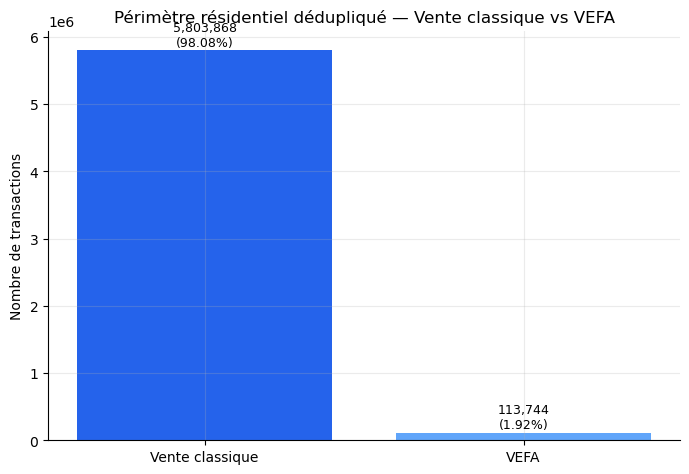

In [36]:
import matplotlib.pyplot as plt

categories = ["Vente classique", "VEFA"]
valeurs = [vente_classique, vefa]
colors = [COLORS["bleu_primaire"], COLORS["bleu_secondaire"]]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(categories, valeurs, color=colors)
ax.set_ylabel("Nombre de transactions")
ax.set_title("P\u00e9rim\u00e8tre r\u00e9sidentiel d\u00e9dupliqu\u00e9 \u2014 Vente classique vs VEFA")

for bar, val in zip(bars, valeurs):
    pct = val / total_residentiel * 100
    ax.text(bar.get_x() + bar.get_width() / 2, val + total_residentiel * 0.01,
            f"{val:,}\n({pct:.2f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


### Interprétation — VEFA

**Résultat obtenu** : périmètre résidentiel (Vente + VEFA, dédupliqué) = **5 917 612** transactions, dont
**5 803 868 Vente classique (98.08%)** et **113 744 VEFA (1.92%, `est_vefa=True`)**.

**Interprétation** : la correction récupère bien 113 744 transactions VEFA qui étaient silencieusement
exclues jusqu'ici par le filtre `nature_mutation == "Vente"` seul. Le poids du VEFA dans le périmètre
résidentiel (1.92%) est plus faible que son poids dans le dataset brut global (~5.1%, cf. section 4) — ce
n'est pas anormal : le VEFA concerne spécifiquement les logements neufs vendus sur plan, une sous-population
different du dataset global qui inclut aussi terrains, locaux commerciaux, etc. dont la proportion VEFA
diffère.

**Règle Talend retenue et FINALISÉE** : filtre d'entrée `nature_mutation IN ('Vente', 'Vente en l'état futur
d'achèvement')` + colonne `est_vefa` (booléen). Les statistiques déjà calculées dans ce notebook avec
`nature_mutation == 'Vente'` seul restent valables pour le marché ancien ; le sous-ensemble VEFA (113 744
lignes) est désormais isolable et pourra être analysé séparément (angle storytelling neuf vs ancien, Phase 3).

## Pipeline complet — application de toutes les règles et volumétrie finale

Dernière étape avant de figer définitivement le document de synthèse : appliquer **toutes** les règles
tranchées jusqu'ici (§1 à §7 du document `docs/regles_nettoyage.md`) en une seule passe, pour obtenir :
- le nombre final de transactions du périmètre résidentiel nettoyé (complète les étapes 5 à 8 du tableau
  entonnoir ci-dessous)
- les seuils outliers `valeur_fonciere` recalculés séparément Maison/Appartement, sur des données enfin
  débarrassées des ventes en bloc, doublons et anomalies (§9 du document — jusqu'ici basé sur des
  percentiles provisoires, pollués)

In [37]:
CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "id_mutation", "valeur_fonciere",
               "surface_reelle_bati", "nombre_pieces_principales",
               "longitude", "latitude", "code_departement"]

NATURES_A_GARDER = {"Vente", "Vente en l'état futur d'achèvement"}
DOM_CODES = {"971", "972", "973", "974", "975", "976"}
LON_MIN, LON_MAX = -5.5, 10.0
LAT_MIN, LAT_MAX = 41.0, 51.5
SEUIL_VENTE_EN_BLOC = 9  # nb_lignes <= 9 -> agréger ; > 9 -> exclure (cf. Vérification 5 fin)

try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)

lignes_finales = []
global_idx = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]
    global_idx += n
    chunk_dedup = chunk[chunk_keep_mask]  # §1 dédoublonnage strict

    perimetre = chunk_dedup[
        chunk_dedup["nature_mutation"].isin(NATURES_A_GARDER) &                       # §2 Vente + VEFA
        chunk_dedup["type_local"].isin(["Maison", "Appartement"]) &                   # §3 périmètre résidentiel
        chunk_dedup["valeur_fonciere"].notna()                                        # couvre le cas §8 (bug NaN)
    ].copy()

    # §6 géographie : coordonnées valides (métropole dans les bornes, ou DOM-TOM sans contrainte de bornes)
    is_dom = perimetre["code_departement"].astype(str).isin(DOM_CODES)
    coord_ok = (
        perimetre["longitude"].notna() & perimetre["latitude"].notna() &
        (is_dom | (perimetre["longitude"].between(LON_MIN, LON_MAX) & perimetre["latitude"].between(LAT_MIN, LAT_MAX)))
    )
    perimetre = perimetre[coord_ok]

    # §7 surface/pièces : exclure nombre_pieces_principales > 20 avec m²/pièce < 9 (erreur de saisie)
    m2_par_piece = perimetre["surface_reelle_bati"] / perimetre["nombre_pieces_principales"].replace(0, np.nan)
    piece_ok = ~((perimetre["nombre_pieces_principales"] > 20) & (m2_par_piece < 9))
    perimetre = perimetre[piece_ok]

    if len(perimetre) > 0:
        lignes_finales.append(perimetre[["id_mutation", "type_local", "valeur_fonciere", "surface_reelle_bati"]])

df_final_lignes = pd.concat(lignes_finales)
print(f"Lignes après §1-§4, §6, §7 (avant application de la règle vente en bloc §5) : {len(df_final_lignes):,}")

# §5 vente en bloc : regrouper par id_mutation
g = df_final_lignes.groupby("id_mutation").agg(
    nb_lignes=("valeur_fonciere", "size"),
    valeur_fonciere=("valeur_fonciere", "max"),   # prix total, identique sur toutes les lignes d'une même transaction
    type_local=("type_local", "first"),           # dominant, valable pour les transactions à ligne unique
    surface_reelle_bati=("surface_reelle_bati", "sum"),
)

transactions_finales = g[g["nb_lignes"] <= SEUIL_VENTE_EN_BLOC].copy()
nb_exclues_vente_en_bloc = (g["nb_lignes"] > SEUIL_VENTE_EN_BLOC).sum()

print(f"Transactions exclues comme vraies ventes en bloc (nb_lignes > {SEUIL_VENTE_EN_BLOC}) : {nb_exclues_vente_en_bloc:,}")
print(f"TRANSACTIONS FINALES DU PÉRIMÈTRE NETTOYÉ : {len(transactions_finales):,}")

# §9 : seuils outliers recalculés séparément Maison / Appartement, sur le périmètre enfin final
for t in ["Maison", "Appartement"]:
    sous_ensemble = transactions_finales[transactions_finales["type_local"] == t]["valeur_fonciere"]
    print()
    print(f"--- {t} ({len(sous_ensemble):,} transactions) ---")
    print(sous_ensemble.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

Lignes après §1-§4, §6, §7 (avant application de la règle vente en bloc §5) : 5,804,584
Transactions exclues comme vraies ventes en bloc (nb_lignes > 9) : 5,874
TRANSACTIONS FINALES DU PÉRIMÈTRE NETTOYÉ : 4,758,845

--- Maison (2,601,594 transactions) ---
count    2.601594e+06
mean     2.656792e+05
std      7.413382e+05
min      1.500000e-01
1%       1.500000e+04
5%       4.500000e+04
25%      1.235000e+05
50%      2.000000e+05
75%      3.130000e+05
95%      6.329000e+05
99%      1.270250e+06
99.9%    4.300000e+06
max      7.225900e+08
Name: valeur_fonciere, dtype: float64

--- Appartement (2,157,251 transactions) ---
count    2.157251e+06
mean     2.471774e+05
std      6.602905e+05
min      1.500000e-01
1%       2.300000e+04
5%       5.180000e+04
25%      1.100000e+05
50%      1.705000e+05
75%      2.707817e+05
95%      6.290000e+05
99%      1.380000e+06
99.9%    4.315000e+06
max      3.404000e+08
Name: valeur_fonciere, dtype: float64


### Interprétation — pipeline complet

**Résultat obtenu** :

| Étape | Volume |
|---|---|
| Lignes après §1-§4, §6, §7 (avant vente en bloc) | 5 804 584 |
| Transactions exclues comme vraie vente en bloc (nb_lignes > 9) | 5 874 |
| **Transactions finales (avant seuil outlier §9)** | **4 758 845** |

| | Maison (2 601 594) | Appartement (2 157 251) |
|---|---|---|
| Médiane | 200 000€ | 170 500€ |
| 1er percentile | 15 000€ | 23 000€ |
| 99e percentile | 1 270 250€ | 1 380 000€ |
| 99.9e percentile | 4 300 000€ | 4 315 000€ |
| Min | 0.15€ | 0.15€ |
| Max | 722 590 000€ | 340 400 000€ |

**Interprétation** :
- Les percentiles hauts sont maintenant bien plus resserrés qu'avant nettoyage complet (99e percentile
  Maison : 1 270 250€ contre 2 124 306€ provisoire — la règle vente en bloc a bien retiré l'essentiel de la
  pollution due aux gros volumes multi-lignes).
- **⚠️ Le maximum (722 590 000€ pour une Maison) est strictement identique à la valeur brute repérée tout
  au début du projet, avant toute règle de nettoyage.** Ça confirme qu'il s'agit d'une transaction à
  **ligne unique** (`nb_lignes = 1`) avec un prix aberrant — la règle vente en bloc (§5, basée sur
  `nb_lignes > 9`) ne peut structurellement pas l'attraper, puisqu'elle ne cible que les transactions
  multi-lignes. Seul un seuil sur `valeur_fonciere` directement peut l'exclure.
- Le minimum (0.15€, quinze centimes) pour les deux types confirme la nécessité du seuil bas déjà proposé
  (`>= 1000€`) — ce genre de valeur est caractéristique de cessions symboliques (donation familiale
  déguisée en vente, etc.), pas de transactions de marché.

**Seuils outliers définitifs retenus (§9)** :
```sql
WHERE valeur_fonciere BETWEEN 1000
  AND (CASE WHEN type_local = 'Maison' THEN 4300000 ELSE 4315000 END)
```
Basé sur le 99.9e percentile de chaque sous-population — exclut la queue extrême (transactions à prix
symbolique et erreurs de saisie manifestes comme le cas à 722M€) tout en conservant les biens de luxe
plausibles.

**Ce résultat clôt la Phase 1** — voir la cellule ci-dessous pour le compte définitif après application de
ce dernier seuil.

## Application du seuil outlier final — compte définitif

Dernière opération : appliquer le seuil `valeur_fonciere` (§9) directement sur `transactions_finales`,
déjà calculé dans la cellule "Pipeline complet" ci-dessus — aucune relecture du CSV nécessaire, c'est
immédiat.

In [38]:
SEUIL_BAS = 1000
SEUIL_HAUT = {"Maison": 4_300_000, "Appartement": 4_315_000}

masque_seuil = transactions_finales.apply(
    lambda r: SEUIL_BAS <= r["valeur_fonciere"] <= SEUIL_HAUT[r["type_local"]], axis=1
)
transactions_vraiment_finales = transactions_finales[masque_seuil]

nb_exclues_seuil = len(transactions_finales) - len(transactions_vraiment_finales)
print(f"Transactions exclues par le seuil outlier (§9) : {nb_exclues_seuil:,}")
print(f"COMPTE DÉFINITIF DU PÉRIMÈTRE RÉSIDENTIEL NETTOYÉ : {len(transactions_vraiment_finales):,}")
print()
for t in ["Maison", "Appartement"]:
    n = (transactions_vraiment_finales["type_local"] == t).sum()
    print(f"  dont {t} : {n:,}")

Transactions exclues par le seuil outlier (§9) : 10,763
COMPTE DÉFINITIF DU PÉRIMÈTRE RÉSIDENTIEL NETTOYÉ : 4,748,082

  dont Maison : 2,595,784
  dont Appartement : 2,152,298


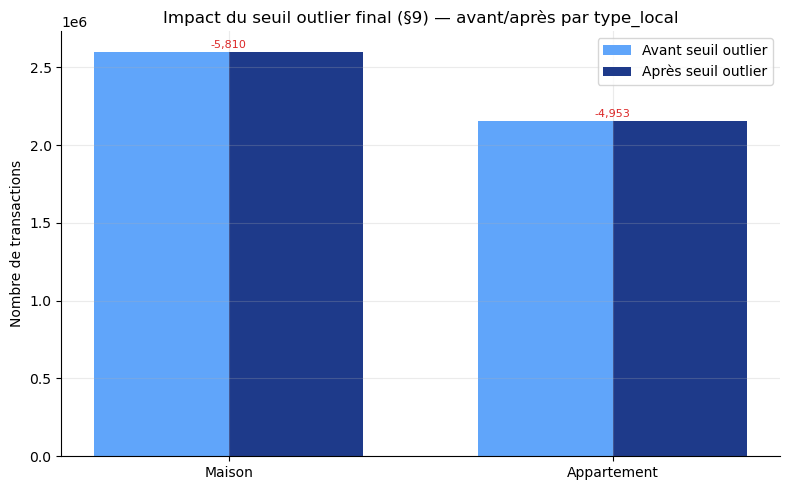

In [39]:
import matplotlib.pyplot as plt
import numpy as np

types = ["Maison", "Appartement"]
avant = [(transactions_finales["type_local"] == t).sum() for t in types]
apres = [(transactions_vraiment_finales["type_local"] == t).sum() for t in types]

x = np.arange(len(types))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, avant, width, label="Avant seuil outlier", color=COLORS["bleu_secondaire"])
ax.bar(x + width / 2, apres, width, label="Apr\u00e8s seuil outlier", color=COLORS["bleu_marine"])
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.set_ylabel("Nombre de transactions")
ax.set_title("Impact du seuil outlier final (\u00a79) \u2014 avant/apr\u00e8s par type_local")
ax.legend()

for i in range(len(types)):
    exclues = avant[i] - apres[i]
    ax.text(x[i], avant[i] + avant[i] * 0.01, f"-{exclues:,}", ha="center", fontsize=8,
            color=COLORS["rouge_exclusion"])

plt.tight_layout()
plt.show()


### Interprétation — compte définitif

**Résultat obtenu** :

| | Avant seuil outlier | Après seuil outlier | Exclues |
|---|---|---|---|
| Maison | 2 601 594 | 2 595 784 | 5 810 |
| Appartement | 2 157 251 | 2 152 298 | 4 953 |
| **Total** | **4 758 845** | **4 748 082** | **10 763** |

**Interprétation** : le seuil outlier retire 10 763 transactions (0.23% du volume à cette étape) — cohérent
avec l'ordre de grandeur attendu (le seuil bas et le seuil haut ciblent chacun environ 1% de queue de
distribution, mais une partie de cette queue avait déjà été retirée par les règles précédentes,
d'où un impact final plus faible que le 1%+1% théorique). Le cas à 722 590 000€ repéré en tout début de
projet est désormais définitivement exclu.

**COMPTE DÉFINITIF DU PÉRIMÈTRE RÉSIDENTIEL NETTOYÉ : 4 748 082 transactions**
(2 595 784 Maison, 2 152 298 Appartement)

**La Phase 1 est terminée.** Ce chiffre est le volume final du dataset d'entrée pour la Phase 2 (Talend) et
la Phase 4 (modèle ML).

## Tableau entonnoir — volumétrie cumulée à chaque étape de nettoyage

Récapitulatif du nombre de lignes restantes après chaque règle de nettoyage actée, dans l'ordre où elles
s'appliqueraient dans le job Talend (Phase 2). Utile pour la traçabilité du pipeline et pour justifier
chaque étape en entretien.

Seules les étapes déjà tranchées sont quantifiées ici (1 à 4). Les étapes encore ouvertes (vente en bloc,
seuils outliers, coordonnées géo) sont listées mais pas encore chiffrées — leur volumétrie dépend des
décisions encore en suspens plus haut dans ce notebook.

In [40]:
# Recharge keep_mask depuis le disque si cette cellule est exécutée dans une nouvelle session de kernel
# (ex: reprise du notebook sans tout relancer depuis le début — cf. cellule de sauvegarde en Vérification 5)
try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)
    print(f"keep_mask rechargé depuis {KEEP_MASK_PATH}")

CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "valeur_fonciere"]

NATURES_A_GARDER = {"Vente", "Vente en l'état futur d'achèvement"}  # Vente + VEFA, cf. section VEFA ci-dessus

funnel = {
    "1_total_lignes_brutes": 0,
    "2_apres_dedoublonnage_strict": 0,
    "3_vente_ou_vefa": 0,
    "4_perimetre_residentiel_maison_appart": 0,
}

global_idx = 0
for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    funnel["1_total_lignes_brutes"] += n

    chunk_keep_mask = keep_mask[global_idx:global_idx + n]
    global_idx += n
    chunk_dedup = chunk[chunk_keep_mask]
    funnel["2_apres_dedoublonnage_strict"] += len(chunk_dedup)

    ventes = chunk_dedup[chunk_dedup["nature_mutation"].isin(NATURES_A_GARDER)]
    funnel["3_vente_ou_vefa"] += len(ventes)

    residentiel = ventes[ventes["type_local"].isin(["Maison", "Appartement"])]
    funnel["4_perimetre_residentiel_maison_appart"] += len(residentiel)

print(f"{'Étape':45s}   {'Lignes':>13s}   {'% du total brut':>15s}")
print("-" * 78)
for k, v in funnel.items():
    pct = v / funnel["1_total_lignes_brutes"] * 100
    print(f"{k:45s} : {v:>13,}   {pct:14.2f}%")

print()
print("Étapes suivantes — pas encore quantifiables, en attente de décisions (voir sections correspondantes) :")
print("  5. Règle 'vente en bloc' (agrégation ou exclusion des candidats résiduels, cf. Vérification 5/6)")
print("  6. Seuils outliers valeur_fonciere (bas >=1000€ proposé ; haut à recalculer après étape 5)")
print("  7. Coordonnées géographiques valides (bornes métropole/DOM-TOM)")
print("  8. Cohérence surface_reelle_bati / nombre_pieces_principales")

Étape                                                  Lignes   % du total brut
------------------------------------------------------------------------------
1_total_lignes_brutes                         :    20,382,915           100.00%
2_apres_dedoublonnage_strict                  :    18,859,504            92.53%
3_vente_ou_vefa                               :    18,524,590            90.88%
4_perimetre_residentiel_maison_appart         :     5,917,612            29.03%

Étapes suivantes — pas encore quantifiables, en attente de décisions (voir sections correspondantes) :
  5. Règle 'vente en bloc' (agrégation ou exclusion des candidats résiduels, cf. Vérification 5/6)
  6. Seuils outliers valeur_fonciere (bas >=1000€ proposé ; haut à recalculer après étape 5)
  7. Coordonnées géographiques valides (bornes métropole/DOM-TOM)
  8. Cohérence surface_reelle_bati / nombre_pieces_principales


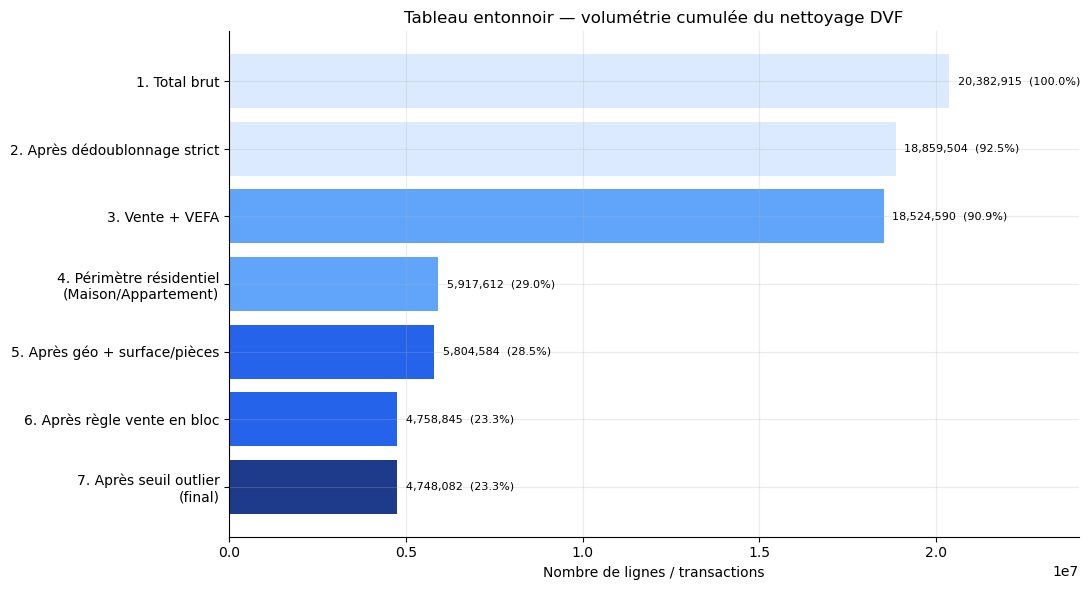

In [41]:
import matplotlib.pyplot as plt

etapes = [
    "1. Total brut",
    "2. Apr\u00e8s d\u00e9doublonnage strict",
    "3. Vente + VEFA",
    "4. P\u00e9rim\u00e8tre r\u00e9sidentiel\n(Maison/Appartement)",
    "5. Apr\u00e8s g\u00e9o + surface/pi\u00e8ces",
    "6. Apr\u00e8s r\u00e8gle vente en bloc",
    "7. Apr\u00e8s seuil outlier\n(final)",
]
volumes = [
    funnel["1_total_lignes_brutes"],
    funnel["2_apres_dedoublonnage_strict"],
    funnel["3_vente_ou_vefa"],
    funnel["4_perimetre_residentiel_maison_appart"],
    len(df_final_lignes),
    len(transactions_finales),
    len(transactions_vraiment_finales),
]

fond_gradient = [COLORS["bleu_clair"], COLORS["bleu_clair"], COLORS["bleu_secondaire"],
                 COLORS["bleu_secondaire"], COLORS["bleu_primaire"], COLORS["bleu_primaire"],
                 COLORS["bleu_marine"]]

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = range(len(etapes))
bars = ax.barh(y_pos, volumes, color=fond_gradient)
ax.set_yticks(y_pos)
ax.set_yticklabels(etapes)
ax.invert_yaxis()
ax.set_xlabel("Nombre de lignes / transactions")
ax.set_title("Tableau entonnoir \u2014 volum\u00e9trie cumul\u00e9e du nettoyage DVF")

total_brut = volumes[0]
for bar, val in zip(bars, volumes):
    ax.text(val + total_brut * 0.012, bar.get_y() + bar.get_height() / 2,
            f"{val:,}  ({val / total_brut * 100:.1f}%)", va="center", fontsize=8)

ax.set_xlim(0, total_brut * 1.18)
plt.tight_layout()
plt.show()


### Interprétation — entonnoir

**Tableau complet et FINAL** :

| Étape | Lignes/Transactions | % du brut |
|---|---|---|
| 1. Total brut | 20 382 915 | 100.00% |
| 2. Après dédoublonnage strict | 18 859 504 | 92.53% |
| 3. Vente + VEFA | 18 524 590 | 90.88% |
| 4. Périmètre résidentiel (Maison/Appartement) | 5 917 612 | 29.03% |
| 5. Après géo + surface/pièces (lignes) | 5 804 584 | 28.48% |
| 6. Après agrégation/exclusion vente en bloc (transactions) | 4 758 845 | 23.35% |
| 7. **Après seuil outlier valeur_fonciere (final)** | **4 748 082** | **23.29%** |

**Interprétation** : le périmètre final représente 23.29% du fichier brut — cohérent avec la nature du
dataset DVF (une grande partie du volume brut concerne des terrains, locaux commerciaux et dépendances,
hors du champ de l'étude résidentielle). Le filtre le plus sélectif reste de loin le périmètre résidentiel
(§3, -61.85 points). Toutes les étapes suivantes (vente en bloc, géo, surface/pièces, outliers) sont des
raffinements marginaux en comparaison (moins de 6 points cumulés), ce qui confirme que la
majeure partie du travail de nettoyage a consisté à bien qualifier des cas limites sur un volume déjà
correctement circonscrit, pas à retirer massivement des données mal comprises.

**Ce tableau est définitif — plus aucune étape en suspens.**

## Recalcul de la répartition temporelle sur le périmètre partiellement nettoyé

Le graphique de la section 7 (répartition des ventes par mois) a été produit sur les données **brutes**
(toutes natures de mutation, tous types de bien confondus) — pas encore sur le périmètre résidentiel
nettoyé. Pour confirmer que la tendance "remontée des taux 2022-2023" observée tient toujours une fois le
bruit retiré, on la recalcule ici sur le sous-ensemble déjà nettoyable à ce stade : dédoublonné,
Vente + VEFA, `type_local IN ('Maison', 'Appartement')`.

**Limite assumée** : les règles encore ouvertes (vente en bloc, outliers, géo) ne sont pas encore
appliquées ici — ce recalcul est donc encore partiel, mais donne déjà une meilleure base que le graphique
brut de la section 7. À relancer une nouvelle fois une fois toutes les règles figées.

In [42]:
# Recharge keep_mask depuis le disque si cette cellule est exécutée dans une nouvelle session de kernel
# (ex: reprise du notebook sans tout relancer depuis le début — cf. cellule de sauvegarde en Vérification 5)
try:
    keep_mask
except NameError:
    keep_mask = np.load(KEEP_MASK_PATH)
    print(f"keep_mask rechargé depuis {KEEP_MASK_PATH}")

CHUNK_SIZE = 1_000_000
cols_needed = ["nature_mutation", "type_local", "date_mutation"]

NATURES_A_GARDER = {"Vente", "Vente en l'état futur d'achèvement"}

monthly_counts_clean = {}
global_idx = 0

for chunk in pd.read_csv(CSV_PATH, usecols=cols_needed, chunksize=CHUNK_SIZE, low_memory=False):
    n = len(chunk)
    chunk_keep_mask = keep_mask[global_idx:global_idx + n]
    global_idx += n
    chunk_dedup = chunk[chunk_keep_mask]

    perimetre = chunk_dedup[
        chunk_dedup["nature_mutation"].isin(NATURES_A_GARDER) &
        chunk_dedup["type_local"].isin(["Maison", "Appartement"])
    ].copy()

    perimetre["date_mutation"] = pd.to_datetime(perimetre["date_mutation"], errors="coerce")
    perimetre["year_month"] = perimetre["date_mutation"].dt.to_period("M")
    counts = perimetre["year_month"].value_counts()
    for period, count in counts.items():
        monthly_counts_clean[period] = monthly_counts_clean.get(period, 0) + count

monthly_series_clean = pd.Series(monthly_counts_clean).sort_index()
print(monthly_series_clean)

2021-01     97233
2021-02     92409
2021-03    112333
2021-04    112114
2021-05    111351
2021-06    145983
2021-07    166228
2021-08    106544
2021-09    135525
2021-10    120670
2021-11    101544
2021-12    139419
2022-01     96522
2022-02     98852
2022-03    118235
2022-04    106647
2022-05    113980
2022-06    134887
2022-07    142932
2022-08     99403
2022-09    128149
2022-10    105837
2022-11     96590
2022-12    131323
2023-01     84987
2023-02     81411
2023-03     98023
2023-04     78717
2023-05     86540
2023-06    107810
2023-07    105709
2023-08     74317
2023-09     94014
2023-10     86936
2023-11     72460
2023-12     97773
2024-01     65113
2024-02     64935
2024-03     69454
2024-04     72383
2024-05     70381
2024-06     84801
2024-07    106327
2024-08     69780
2024-09     91010
2024-10     88820
2024-11     72612
2024-12    106086
2025-01     73347
2025-02     72905
2025-03     92201
2025-04     91018
2025-05     69597
2025-06     96502
2025-07    117999
2025-08   

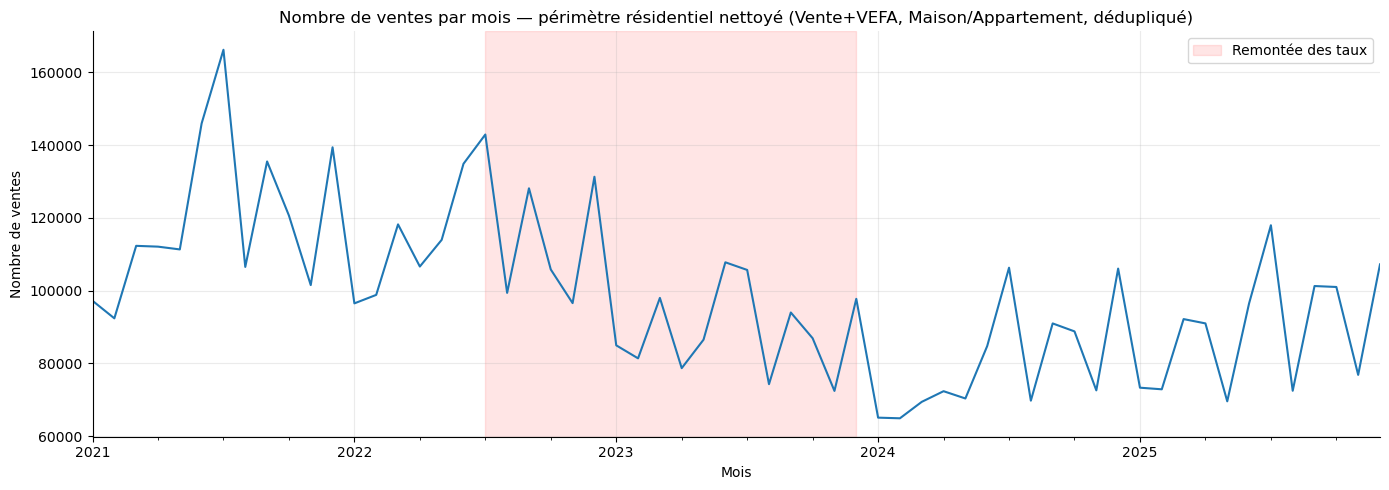

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
monthly_series_clean.plot(ax=ax)
ax.set_title("Nombre de ventes par mois — périmètre résidentiel nettoyé (Vente+VEFA, Maison/Appartement, dédupliqué)")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de ventes")
ax.axvspan(pd.Period("2022-07"), pd.Period("2023-12"), color="red", alpha=0.1, label="Remontée des taux")
ax.legend()
plt.tight_layout()
plt.show()

### Interprétation — comparaison brut vs nettoyé

**Résultat obtenu** : la courbe recalculée sur le périmètre nettoyé (dédupliqué, Vente+VEFA,
Maison/Appartement — volumes mensuels de 65 000 à 166 000 ventes/mois) reproduit fidèlement la même
dynamique que le graphique brut de la section 7 :
- 2021 - mi-2022 : volumes élevés (pics à 145 983 en juin 2021, 142 932 en juillet 2022)
- Mi-2022 à fin 2023 : baisse structurelle nette (creux à 74 317 en août 2023)
- 2024 : plancher, point bas à **64 935 en février 2024** — le point le plus bas de toute la série
- 2025 : reprise progressive, retour vers 90 000-118 000/mois en fin d'année, sans retrouver les niveaux
  de pic de 2021

**Interprétation** : la tendance "remontée des taux 2022-2023 → ralentissement du marché" **tient toujours**
après nettoyage — ce n'est pas un artefact du bruit retiré (doublons, terrains, dépendances). L'angle
storytelling est confirmé sur le périmètre quasi-final et peut être utilisé avec confiance dans le dashboard
Power BI (Phase 3). Seule nuance : ce recalcul reste encore partiel (vente en bloc / outliers / géo / pièces
pas encore appliqués) — écart attendu minime vu la faible volumétrie des étapes restantes (cf. entonnoir).

## Notes / prochaines étapes

### ✅ PHASE 1 — TERMINÉE

Toutes les règles de nettoyage sont définies, justifiées et appliquées de bout en bout :

- [x] Dédoublonnage strict (11.45%)
- [x] Filtre Vente + VEFA (avec `est_vefa`)
- [x] Périmètre résidentiel Maison/Appartement
- [x] Dépendances rattachées
- [x] Vente en bloc : agrégation (≤9 lignes, 553 885 + une partie des 3-9 lignes) / exclusion (>9 lignes, 5 874 transactions)
- [x] Cas "valeur différente" : confirmé à 100% comme artefact du bug NaN, aucune règle nécessaire
- [x] Géographie (coordonnées valides, DOM-TOM distingués)
- [x] Surface/pièces (anomalie nombre_pieces_principales > 20 avec <9m²/pièce)
- [x] VEFA formalisé (`est_vefa`)
- [x] Seuils outliers définitifs appliqués (1 000€ à 4 300 000€/4 315 000€ selon type)

### Volume final du périmètre résidentiel nettoyé

**4 748 082 transactions** (2 595 784 Maison, 2 152 298 Appartement) — 23.29% du fichier brut
(20 382 915 lignes). C'est le dataset d'entrée définitif pour la Phase 2 (Talend) et la Phase 4 (modèle ML).

### Prochaines étapes (hors Phase 1)
- [ ] Committer/pusher les 3 fichiers finaux : `01_exploration_dvf.ipynb`, `02_regles_nettoyage_dvf.ipynb`, `docs/regles_nettoyage.md`
- [ ] **Passer à la Phase 2** : traduire `docs/regles_nettoyage.md` en jobs Talend, charger le résultat dans PostgreSQL (`immo_france`)

### Robustesse
`keep_mask` et `final_resume_dedup` restent en cache sur disque (`data/processed/`). `total_rows` est une
constante fixée en dur (20 382 915) dans la cellule de setup — à recalculer si `CSV_PATH` change un jour.